# This notbook contains codes that generate figures 2-5 in the main manuscript

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
from datetime import timedelta
from datetime import datetime, time
import math
import glob

In [7]:
folder_path = Path('./all_flight_arrival_data_New')
airport_list = []
annual_flight_count_list = []
avg_daily_flight_count_list = []
daily_flight_count_list = []
for file_path in folder_path.glob('*.csv'):
    all_flights = pd.read_csv(file_path)
    airport = all_flights['Destination Airport'].iloc[0]
    annual_flight_counts = len(all_flights)
    daily_flight_counts = all_flights.groupby('Date (MM/DD/YYYY)').size().reset_index()
    daily_flight_counts = daily_flight_counts.rename(columns={0: 'flight_counts'})
    daily_flight_counts_avg = round(daily_flight_counts['flight_counts'].mean())
    airport_list.append(airport)
    annual_flight_count_list.append(annual_flight_counts)
    avg_daily_flight_count_list.append(daily_flight_counts_avg)
    daily_flight_counts['airport'] = airport
    daily_flight_count_list.append(daily_flight_counts)
avg_daily_flight_count_df = pd.DataFrame({'airport': airport_list, 'flight_count': avg_daily_flight_count_list})
annual_flight_count_df = pd.DataFrame({'airport': airport_list, 'flight_count': annual_flight_count_list})
daily_flight_count_df = pd.concat(daily_flight_count_list)

In [11]:
us_airports_gps = pd.read_csv('./us_airports_gps.csv')
us_airports_gps = us_airports_gps.dropna(subset='iata_code')

In [14]:
annual_flight_count_df_location = pd.merge(annual_flight_count_df, us_airports_gps[['iata_code', 'latitude_deg', 'longitude_deg', 'region_name']], left_on='airport', right_on='iata_code', how='inner')

In [15]:
annual_flight_count_mainland = annual_flight_count_df_location[(annual_flight_count_df_location.region_name != 'Alaska') & (annual_flight_count_df_location.region_name != 'Hawaii') & (annual_flight_count_df_location.region_name != 'Rhode Island')]

In [16]:
us_airports_gps = pd.read_csv('./us_airports_gps.csv')
us_airports_gps = us_airports_gps.dropna(subset='iata_code')
annual_flight_count_df_location = pd.merge(annual_flight_count_df, us_airports_gps[['iata_code', 'latitude_deg', 'longitude_deg', 'region_name']], left_on='airport', right_on='iata_code', how='inner')
annual_flight_count_mainland = annual_flight_count_df_location[(annual_flight_count_df_location.region_name != 'Alaska') & (annual_flight_count_df_location.region_name != 'Hawaii') & (annual_flight_count_df_location.region_name != 'Rhode Island')]
mainland_airports = annual_flight_count_mainland.iata_code.to_list()

### Figure 2a

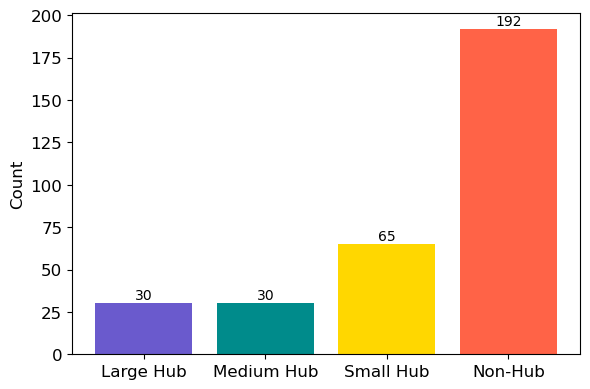

In [ ]:
import matplotlib.pyplot as plt

# Data
categories = ['Large Hub', 'Medium Hub', 'Small Hub', 'Non-Hub']
values = [30, 30, 65, 192]

# Plot
plt.figure(figsize=(6, 4))
bars = plt.bar(categories, values, color=['slateblue', 'darkcyan', 'gold', 'tomato'])

# Add value labels above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, str(yval), ha='center', va='bottom')

plt.ylabel('Count', fontsize = 12)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)

plt.tight_layout()

plt.savefig("/Figure2_a.pdf", format='pdf', bbox_inches='tight')

plt.show()

### Figure 2b

In [20]:
import geopandas as gpd
from shapely.geometry import Point
annual_flight_count_mainland['geometry'] = annual_flight_count_mainland.apply(lambda row: Point(row['longitude_deg'], row['latitude_deg']), axis=1)
annual_flight_count_mainland_gdf = gpd.GeoDataFrame(annual_flight_count_mainland, geometry='geometry', crs='EPSG:4326')

/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_87340/3099706074.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  annual_flight_count_mainland['geometry'] = annual_flight_count_mainland.apply(lambda row: Point(row['longitude_deg'], row['latitude_deg']), axis=1)


In [21]:
FAA_category = pd.read_excel('./FAA_airport classification.xlsx')

In [23]:
annual_flight_count_mainland_FAA = pd.merge(annual_flight_count_mainland_gdf, FAA_category[['Airport Identifier (LOC ID)', 'Hub Size']], left_on='airport', right_on='Airport Identifier (LOC ID)', how='left')


In [25]:
annual_flight_count_mainland_large = annual_flight_count_mainland_FAA[annual_flight_count_mainland_FAA['Hub Size'] == 'Large']
annual_flight_count_mainland_medium = annual_flight_count_mainland_FAA[annual_flight_count_mainland_FAA['Hub Size'] == 'Medium']
annual_flight_count_mainland_small = annual_flight_count_mainland_FAA[annual_flight_count_mainland_FAA['Hub Size'] == 'Small']
annual_flight_count_mainland_non_hub = annual_flight_count_mainland_FAA[~annual_flight_count_mainland_FAA['Hub Size'].isin(['Large', 'Small', 'Medium'])]

In [26]:
annual_flight_count_mainland_large['flight_count'].max()

np.int64(376880)

In [22]:
annual_flight_count_mainland_large['flight_count'].min()

np.int64(88464)

In [23]:
annual_flight_count_mainland_medium['flight_count'].max()

np.int64(92295)

In [24]:
annual_flight_count_mainland_medium['flight_count'].min()

np.int64(25883)

In [25]:
annual_flight_count_mainland_small['flight_count'].max()

np.int64(73578)

In [26]:
annual_flight_count_mainland_small['flight_count'].min()

np.int64(5009)

In [27]:
annual_flight_count_mainland_non_hub['flight_count'].max()

np.int64(10612)

In [28]:
annual_flight_count_mainland_non_hub['flight_count'].min()

np.int64(71)

In [29]:
len(annual_flight_count_mainland_large)

30

In [30]:
len(annual_flight_count_mainland_medium)

30

In [31]:
len(annual_flight_count_mainland_small)

65

In [35]:
len(annual_flight_count_mainland_non_hub)

192

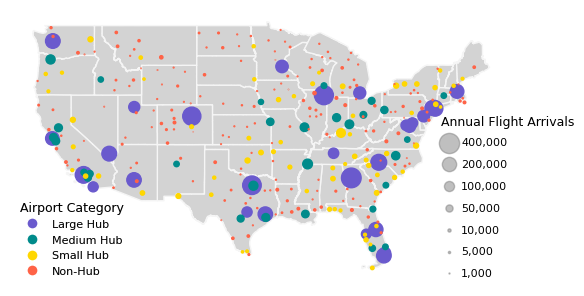

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.lines import Line2D


# Update this path to where you extracted the Natural Earth shapefile
shapefile_path = "./tl_2025_us_state/tl_2025_us_state.shp"

# Load the shapefile into a GeoDataFrame
us = gpd.read_file(shapefile_path)
# if us.crs is None:
#     us = us.set_crs(epsg=4269)

# Filter for US mainland (excluding Alaska and Hawaii)
us_mainland = us[(us['NAME'] != 'Puerto Rico') & (us['NAME'] != 'Hawaii') & (us['NAME'] != 'Alaska') & (us['NAME'] !='U.S. Virgin Islands')]
us_mainland = us_mainland.cx[-130:-65, 24:50]
# us_mainland = us_mainland.to_crs(epsg=3857)
# Set up plot
fig, ax = plt.subplots(figsize=(6, 4))

# Normalize size
max_size = annual_flight_count_mainland_FAA['flight_count'].max()
scale_factor = 200
normalize_size = lambda x: (x / max_size) * scale_factor

# Plot base map
us_mainland.plot(ax=ax, color='lightgrey', edgecolor='whitesmoke')

# Plot airport categories
annual_flight_count_mainland_large.plot(ax=ax, markersize=normalize_size(annual_flight_count_mainland_large['flight_count']), color='slateblue', label='Large Hub')
annual_flight_count_mainland_medium.plot(ax=ax, markersize=normalize_size(annual_flight_count_mainland_medium['flight_count']), color='darkcyan', label='Medium Hub')
annual_flight_count_mainland_small.plot(ax=ax, markersize=normalize_size(annual_flight_count_mainland_small['flight_count']), color='gold', label='Small Hub')
annual_flight_count_mainland_non_hub.plot(ax=ax, markersize=normalize_size(annual_flight_count_mainland_non_hub['flight_count']), color='tomato', label='Non-Hub')

# Custom legend for color (category)
color_legend = [
    Line2D([0], [0], marker='o', color='w', label='Large Hub', markerfacecolor='slateblue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Medium Hub', markerfacecolor='darkcyan', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Small Hub', markerfacecolor='gold', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Non-Hub', markerfacecolor='tomato', markersize=8)
]
legend1 = ax.legend(handles=color_legend, title='Airport Category', loc = 'lower left', fontsize=8, title_fontsize=9)
ax.add_artist(legend1)
legend1.get_frame().set_linewidth(0)

# Custom size scale (marker size)
example_counts = [1000, 5000, 10000, 50000, 100000, 200000, 400000]  # adjust as needed
x_pos, y_pos = -125, 24  # adjust position to fit map
for i, count in enumerate(example_counts):
    y = y_pos + i * 2.2
    size = normalize_size(count)
    ax.scatter(x_pos+53, y, s=size, color='gray', alpha=0.5)
    ax.text(x_pos + 54.5, y, f'{count:,}', va='center', fontsize=8)

ax.text(x_pos+52, y_pos + len(example_counts)*2+1, 'Annual Flight Arrivals', fontsize=9)

# Remove border and axes
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Figure2_b.pdf", format='pdf', bbox_inches='tight')
plt.show()

### Figure 2c

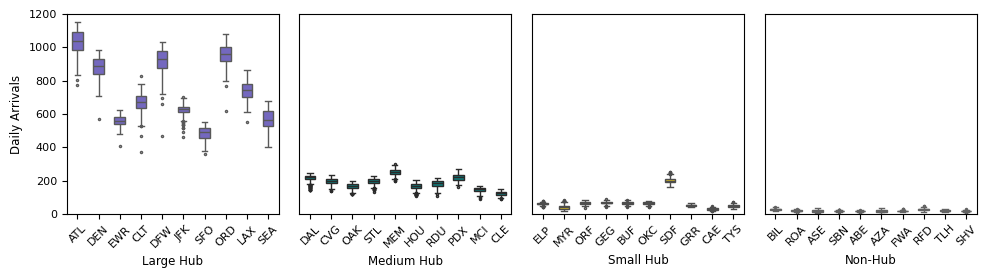

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert 'date' to datetime if not already
daily_flight_count_df['date'] = pd.to_datetime(daily_flight_count_df['Date (MM/DD/YYYY)'])

grouped_airports = {
'Large Hub': ['ATL', 'DEN', 'DFW', 'ORD', 'LAX', 'SFO', 'SEA', 'JFK', 'CLT', 'EWR'],
'Medium Hub': ['MEM', 'PDX', 'DAL', 'CVG', 'STL', 'OAK', 'HOU', 'RDU', 'MCI', 'CLE'],
'Small Hub': ['SDF', 'GEG', 'OKC', 'ORF', 'BUF', 'ELP', 'MYR', 'TYS', 'CAE', 'GRR'],
'Non-Hub': ['BIL', 'RFD', 'TLH', 'FWA', 'ROA', 'AZA', 'SHV', 'ABE', 'SBN', 'ASE']
}

colors = ['slateblue', 'darkcyan', 'gold', 'tomato']
# Create 4x1 subplots
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
axes = axes.flatten()

# Plot one boxplot per group
for i, (category, airports) in enumerate(grouped_airports.items()):
    df_subset = daily_flight_count_df[daily_flight_count_df['airport'].isin(airports)]
    sns.boxplot(data=df_subset, x='airport', y='flight_counts', color = colors[i], ax=axes[i],fliersize=1.5,width=0.5)
    # axes[i].set_title(f"{category}", fontsize=12)
    axes[i].set_xlabel(f"{category}", fontsize=8.5)
    # axes[i].set_ylabel("Daily Arrivals")
    axes[i].tick_params(axis='x', labelsize =8, rotation=45) #rotation=45
    axes[i].set_ylim(0,1200)
    if i !=0:
        axes[i].set_ylabel("")
        axes[i].tick_params(axis='y', left=False, labelleft=False, labelsize =7)
    else:
        axes[i].tick_params(axis='y',labelsize =8)
        axes[i].set_ylabel("Daily Arrivals", fontsize = 8.5)

# Adjust layout
# plt.suptitle("Daily Flight Arrival Distributions by Airport Category", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("Figure2_c.pdf", format='pdf', bbox_inches='tight')

plt.show()

### Figure 2d

In [59]:
folder_path = Path('./all_flight_arrival_data_New')
airport_list = []
avg_hourly_flight_count_list = []
for file_path in folder_path.glob('*.csv'):
    all_flights = pd.read_csv(file_path)
    airport = all_flights['Destination Airport'].iloc[0]
    all_flights['hour'] = all_flights['Actual Arrival Time'].apply(lambda x: x.split(':')[0])
    hourly_flight_count = all_flights.groupby(['Date (MM/DD/YYYY)', 'hour']).size().reset_index(name='count')
    avg_hourly_flight_count = hourly_flight_count.groupby('hour')['count'].mean().reset_index()
    avg_hourly_flight_count['airport'] = airport
    avg_hourly_flight_count_list.append(avg_hourly_flight_count)

avg_hourly_flight_count_df = pd.concat(avg_hourly_flight_count_list)

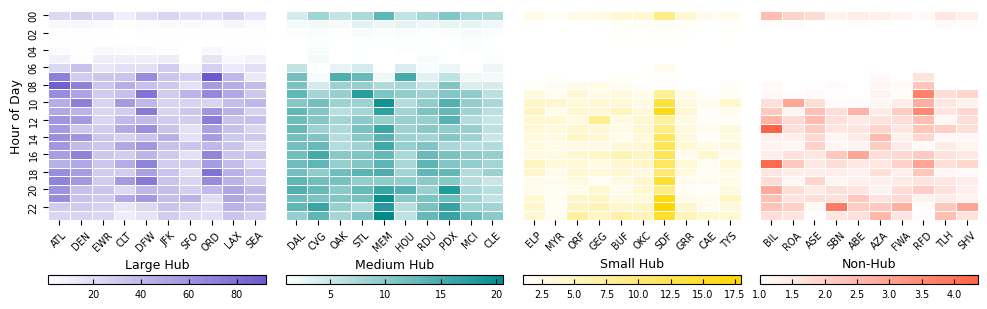

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import seaborn as sns

grouped_airports = {
    'Large Hub': ['ATL', 'DEN', 'EWR', 'CLT', 'DFW', 'JFK', 'SFO', 'ORD', 'LAX',  'SEA'],
    'Medium Hub': ['DAL', 'CVG', 'OAK', 'STL', 'MEM', 'HOU', 'RDU', 'PDX', 'MCI', 'CLE'],
    'Small Hub': ['ELP', 'MYR', 'ORF', 'GEG', 'BUF', 'OKC', 'SDF', 'GRR', 'CAE', 'TYS'],
    'Non-Hub': ['BIL', 'ROA', 'ASE', 'SBN', 'ABE', 'AZA', 'FWA', 'RFD', 'TLH', 'SHV']
}

# Define custom colormaps
cmap_large = LinearSegmentedColormap.from_list("slateblue_fade", ["white", "slateblue"])
cmap_medium = LinearSegmentedColormap.from_list("darkcyan_fade", ["white", "darkcyan"])
cmap_small = LinearSegmentedColormap.from_list("gold_fade", ["white", "gold"])
cmap_nonhub = LinearSegmentedColormap.from_list("tomato_fade", ["white", "tomato"])
cmaps = [cmap_large, cmap_medium, cmap_small, cmap_nonhub]

fig, axes = plt.subplots(1, 4, figsize=(10, 3.2), sharey=True)

for i, (category, airports) in enumerate(grouped_airports.items()):
    df_subset = avg_hourly_flight_count_df[avg_hourly_flight_count_df['airport'].isin(airports)]
    heatmap_data = df_subset.pivot(index="hour", columns="airport", values="count")[airports]

    # hm=sns.heatmap(
    #     heatmap_data,
    #     cmap=cmaps[i],
    #     linewidths=0.5,
    #     ax=axes[i],
    #     cbar=True,
    #     cbar_kws={'shrink': 0.6}
    # )
    # hm.collections[0].colorbar.ax.tick_params(labelsize=7)

    hm = sns.heatmap(
    heatmap_data,
    cmap=cmaps[i],
    linewidths=0.5,
    ax=axes[i],
    cbar=False  # disable default colorbar
    )

    # Add colorbar above the subplot
    cbar = fig.colorbar(
    hm.collections[0],
    ax=axes[i],
    orientation='horizontal',
    fraction=0.05,  # relative size of the colorbar
    pad=0.2,        # space between plot and colorbar
    aspect=25
    )
    cbar.ax.tick_params(labelsize=7, direction='in', labelbottom=True, labeltop=False)


    # # Get the colorbar
    # colorbar = hm.collections[0].colorbar

    # # Generate integer ticks within the value range
    # vmin = int(np.floor(colorbar.vmin))
    # vmax = int(np.ceil(colorbar.vmax))
    # ticks = list(range(vmin, vmax + 1, max(1, (vmax - vmin) // 4)))  # 4 steps max

    # axes[i].set_title(category, fontsize=10)
    axes[i].set_xlabel(f'{category}', fontsize=9)
    axes[i].tick_params(axis='x', labelsize=7, rotation=90)
    axes[i].set_xticks(np.arange(len(airports)) + 0.5)
    axes[i].set_xticklabels(airports, rotation=45, fontsize=7)

    if i == 0:
        axes[i].set_ylabel("Hour of Day", fontsize=9)
        axes[i].tick_params(axis='y', labelsize=7)
    else:
        axes[i].set_ylabel("")
        axes[i].tick_params(axis='y', left=False, labelleft=False)

plt.tight_layout() #rect=[0, 0, 1, 0.95]
plt.savefig("Figure2_d.pdf", format='pdf', bbox_inches='tight')

plt.show()

### Figure 5

In [70]:
# vehicle and charger counts for each scenario
veh_folder = './all_flight_GSE_vehicle_count'
cha_folder = './all_flight_GSE_charger_count'

files_folder1 = [f for f in os.listdir(veh_folder) if f.endswith('.csv')]
files_folder2 = [f for f in os.listdir(cha_folder) if f.endswith('.csv')]

for file1 in files_folder1:

    common_string = file1.split('_')[-1].split('.')[0] 
    
    # Search for a corresponding file in folder2
    for file2 in files_folder2:
        if common_string in file2:
            # Read the CSV files
            df1 = pd.read_csv(os.path.join(veh_folder, file1))
            # df1 = df1[df1]
            df2 = pd.read_csv(os.path.join(cha_folder, file2))
            
            # Merge dataframes (you can specify how to merge based on your requirements)
            merged_df = pd.merge(df1, df2, on='airport', how='left')
            merged_df.to_csv(f'./all_flight_GSE_vehicle_count/veh_cha_count/veh_cha_count_{common_string}.csv', index=False)

In [61]:
veh_cha_count_S1 = pd.read_csv('./all_flight_GSE_vehicle_count/veh_cha_count/veh_cha_count_S1.csv')
veh_cha_count_S2 = pd.read_csv('./all_flight_GSE_vehicle_count/veh_cha_count/veh_cha_count_S2.csv')
veh_cha_count_S3 = pd.read_csv('./all_flight_GSE_vehicle_count/veh_cha_count/veh_cha_count_S3.csv')
veh_cha_count_S4 = pd.read_csv('./all_flight_GSE_vehicle_count/veh_cha_count/veh_cha_count_S4.csv')
veh_cha_count_S5 = pd.read_csv('./all_flight_GSE_vehicle_count/veh_cha_count/veh_cha_count_S5.csv')
veh_cha_count_S6 = pd.read_csv('./all_flight_GSE_vehicle_count/veh_cha_count/veh_cha_count_S6.csv')

In [62]:
veh_cha_count_S1['GPU_counts'] = veh_cha_count_S1['GPU_counts_narrow'] + veh_cha_count_S1['GPU_counts_wide']
veh_cha_count_S1['aircraft_tractor_counts'] = veh_cha_count_S1['aircraft_tractor_counts_narrow'] + veh_cha_count_S1['aircraft_tractor_counts_wide']
veh_cha_count_S1['belt_loader_counts'] = veh_cha_count_S1['belt_loader_counts_narrow'] + veh_cha_count_S1['belt_loader_counts_wide']
veh_cha_count_S1['lav_truck_counts'] = veh_cha_count_S1['lav_truck_counts_narrow'] + veh_cha_count_S1['lav_truck_counts_wide']
veh_cha_count_S1['water_truck_counts'] = veh_cha_count_S1['water_truck_counts_narrow'] + veh_cha_count_S1['water_truck_counts_wide']
veh_cha_count_S1['cargo_loader_counts'] = veh_cha_count_S1['cargo_loader_counts_wide']

In [63]:
veh_cha_count_S1

,Unnamed: 0_x,baggage_tractor_counts,cater_truck_counts,GPU_counts_narrow,aircraft_tractor_counts_narrow,belt_loader_counts_narrow,lav_truck_counts_narrow,water_truck_counts_narrow,GPU_counts_wide,aircraft_tractor_counts_wide,...,cargo_loader_counts_wide,airport,Unnamed: 0_y,charger_count,GPU_counts,aircraft_tractor_counts,belt_loader_counts,lav_truck_counts,water_truck_counts,cargo_loader_counts
0,0,6,3,3,3,3,3,3,0,0,...,0,PIB,322,7,3,3,3,3,3,0
1,1,252,147,146,105,116,94,93,24,10,...,22,DTW,256,149,170,115,127,102,101,22
2,2,13,7,7,7,6,5,5,1,1,...,2,ERI,103,10,8,8,7,6,6,2
3,3,12,6,7,5,7,5,5,0,0,...,0,FSM,264,8,7,5,7,5,5,0
4,4,87,47,51,41,42,35,36,1,1,...,2,GRR,125,35,52,42,43,36,37,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,345,52,34,29,23,24,21,20,2,2,...,4,LIH,294,33,31,25,26,23,22,4
346,346,8,4,4,4,4,4,3,0,0,...,0,HIB,4,7,4,4,4,4,3,0
347,347,25,13,14,11,11,9,9,1,1,...,2,ISP,70,18,15,12,12,10,10,2
348,348,31,19,18,14,15,13,12,1,1,...,2,GJT,219,18,19,15,16,14,13,2


In [64]:
veh_cha_count_S1_large = veh_cha_count_S1[veh_cha_count_S1['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
veh_cha_count_S1_large['category'] = 'Large Hub'
veh_cha_count_S1_medium = veh_cha_count_S1[veh_cha_count_S1['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
veh_cha_count_S1_medium['category'] = 'Medium Hub'
veh_cha_count_S1_small = veh_cha_count_S1[veh_cha_count_S1['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
veh_cha_count_S1_small['category'] = 'Small Hub'
veh_cha_count_S1_nonhub = veh_cha_count_S1[veh_cha_count_S1['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]
veh_cha_count_S1_nonhub['category'] = 'Non-Hub'

/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_87340/3641384872.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_cha_count_S1_large['category'] = 'Large Hub'
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_87340/3641384872.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_cha_count_S1_medium['category'] = 'Medium Hub'
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_87340/3641384872.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

0
[np.float64(202.1), np.float64(129.2), np.float64(296.2), np.float64(36.46666666666667), np.float64(142.4), np.float64(169.2), np.float64(115.06666666666666), np.float64(110.6)]
1
[np.float64(77.8), np.float64(55.96666666666667), np.float64(121.23333333333333), np.float64(8.2), np.float64(59.96666666666667), np.float64(69.13333333333334), np.float64(49.1), np.float64(46.96666666666667)]
2
[np.float64(36.76923076923077), np.float64(28.46153846153846), np.float64(60.738461538461536), np.float64(2.953846153846154), np.float64(30.16923076923077), np.float64(34.30769230769231), np.float64(25.323076923076922), np.float64(24.70769230769231)]
3
[np.float64(10.65625), np.float64(8.822916666666666), np.float64(18.75), np.float64(0.9375), np.float64(9.229166666666666), np.float64(10.197916666666666), np.float64(8.041666666666666), np.float64(7.8125)]


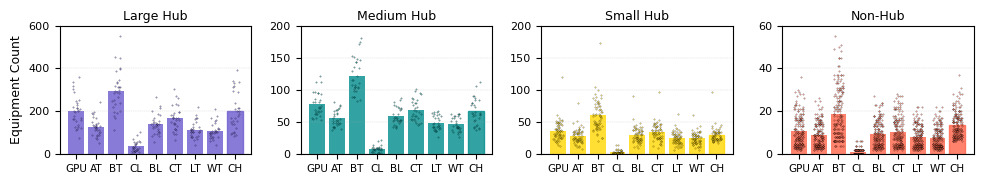

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# Set the overall font and style
mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 11,
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.3,
    'grid.alpha': 0.3
})

# Combine all DataFrames
df = pd.concat([veh_cha_count_S1_large, veh_cha_count_S1_medium,
                veh_cha_count_S1_small, veh_cha_count_S1_nonhub], ignore_index=True)

gse_cols = [
    'GPU_counts', 'aircraft_tractor_counts', 'baggage_tractor_counts',
    'cargo_loader_counts', 'belt_loader_counts', 'cater_truck_counts',
    'lav_truck_counts', 'water_truck_counts'
]
charger_col = 'charger_count'
equipment_labels = gse_cols + ['Charger']
categories = ['Large Hub', 'Medium Hub', 'Small Hub', 'Non-Hub']

# Use more muted, professional colors
#colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
colors = ['slateblue', 'darkcyan', 'gold', 'tomato']

# Set x positions for the bars (one for each equipment type, including charger)
x = np.arange(len(equipment_labels))  # 9 equipment types
bar_width = 0.8  # Make the bar width wider (increased from 0.4)

# Create the subplots
fig, axes = plt.subplots(1, 4, figsize=(10, 2),sharey=False)
axes = axes.flatten()

# Iterate over categories and plot on corresponding axes
for i, cat in enumerate(categories):
    ax = axes[i]  # Get the appropriate axis for the current category
    print(i)

    # Bar plots for GSEs
    gse_vals = [df[df['category'] == cat][col].mean() for col in gse_cols]
    print(gse_vals)

    # Plot bars automatically with bar width and position adjustment
    ax.bar(x[:-1], gse_vals, width=bar_width, color=colors[i], label=cat, alpha=0.8, edgecolor='none')

    # Scatter plots for GSEs
    cat_df = df[df['category'] == cat]
    for j, col in enumerate(gse_cols):
        y_vals = cat_df[col].values
        x_base = x[j]  # We use x[j] directly as positions for GSE bars
        jitter = (np.random.rand(len(y_vals)) - 0.5) * bar_width * 0.6
        x_vals = np.full(len(y_vals), x_base) + jitter
        ax.scatter(x_vals, y_vals, color=colors[i], edgecolors='black', s=1, alpha=0.5, linewidths=0.3)

    # Bar plot for Charger (always at the last position)
    charger_val = df[df['category'] == cat][charger_col].mean()
    charger_bar = ax.bar(x[-1], charger_val, width=bar_width, color=colors[i], alpha=0.8, edgecolor=colors[i])

    # Scatter plots for Charger
    charger_vals = df[df['category'] == cat][charger_col].values
    jitter = (np.random.rand(len(charger_vals)) - 0.5) * bar_width * 0.6
    x_vals = np.full(len(charger_vals), x[-1]) + jitter
    ax.scatter(x_vals, charger_vals, color=colors[i], edgecolors='black', s=1, alpha=0.5, linewidths=0.3)

    # Aesthetics
    equip_list = ['GPU','Aircraft Tractor','Baggage Tractor','Cargo Loader','Belt Loader','Cater Truck','Lav Truck','Water Truck','Charger']
    equip_list_abb = ['GPU','AT','BT','CL','BL','CT','LT','WT','CH']
    ax.set_xticks(x)  # Now using the full range of x
    ax.set_xticklabels(equip_list_abb, rotation=0, ha='center', fontsize=7.5)  # Ensure center alignment
    axes[0].set_ylim(0, 600)
    axes[1].set_ylim(0, 200)
    axes[2].set_ylim(0, 200)
    axes[3].set_ylim(0, 60)
    ax.set_xlabel(cat, fontsize=9)
    ax.xaxis.set_label_position('top')
    ax.spines['top'].set_visible(True)  # Enable top border
    ax.spines['right'].set_visible(True)  # Enable right border
    ax.spines['bottom'].set_visible(True)  # Enable bottom border
    ax.spines['left'].set_visible(True)  # Enable left border
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)  # Enable grid for each subplot

    # Set title for each subplot
    #ax.set_title(f'{cat} Equipment and Charger Counts')
    #ax.set_yscale('log')
    # Remove y-label for all but the first subplot
    if i != 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Equipment Count')
    ax.tick_params(axis='y', left=True, labelleft=True, labelsize =8)

    # # Add legend for the first subplot only
    # if i == 0:
    #     ax.legend(
    #         title='Airport Category',
    #         loc='upper center',
    #         bbox_to_anchor=(0.5, 1.13),  # adjust position above the plot
    #         ncol=len(categories),        # one column per category
    #         frameon=False,
    #         title_fontsize=12,
    #         fontsize=10
    #     )

# Adjust spacing between subplots and increase bottom space for better x-labels
plt.subplots_adjust(wspace=0.3, bottom=0.25)  # Increased bottom space to avoid label overlap

# Increase font size for the y-ticks if necessary
plt.tight_layout()
plt.savefig("/Figure5_a.pdf", format='pdf', bbox_inches='tight')
plt.show()


In [50]:
veh_cha_count_S2['GPU_counts'] = veh_cha_count_S2['GPU_counts_narrow'] + veh_cha_count_S2['GPU_counts_wide']
veh_cha_count_S2['aircraft_tractor_counts'] = veh_cha_count_S2['aircraft_tractor_counts_narrow'] + veh_cha_count_S2['aircraft_tractor_counts_wide']
veh_cha_count_S2['belt_loader_counts'] = veh_cha_count_S2['belt_loader_counts_narrow'] + veh_cha_count_S2['belt_loader_counts_wide']
veh_cha_count_S2['lav_truck_counts'] = veh_cha_count_S2['lav_truck_counts_narrow'] + veh_cha_count_S2['lav_truck_counts_wide']
veh_cha_count_S2['water_truck_counts'] = veh_cha_count_S2['water_truck_counts_narrow'] + veh_cha_count_S2['water_truck_counts_wide']
veh_cha_count_S2['cargo_loader_counts'] = veh_cha_count_S2['cargo_loader_counts_wide']

In [52]:
# Difference between S2 and S1
veh_cha_count_S2_S1_diff = veh_cha_count_S2.copy()
veh_cha_count_S2_S1_diff['GPU_counts'] = veh_cha_count_S2['GPU_counts'] - veh_cha_count_S1['GPU_counts']
veh_cha_count_S2_S1_diff['aircraft_tractor_counts'] = veh_cha_count_S2['aircraft_tractor_counts'] - veh_cha_count_S1['aircraft_tractor_counts']
veh_cha_count_S2_S1_diff['baggage_tractor_counts'] = veh_cha_count_S2['baggage_tractor_counts'] - veh_cha_count_S1['baggage_tractor_counts']
veh_cha_count_S2_S1_diff['cargo_loader_counts'] = veh_cha_count_S2['cargo_loader_counts'] - veh_cha_count_S1['cargo_loader_counts']
veh_cha_count_S2_S1_diff['belt_loader_counts'] = veh_cha_count_S2['belt_loader_counts'] - veh_cha_count_S1['belt_loader_counts']
veh_cha_count_S2_S1_diff['cater_truck_counts'] = veh_cha_count_S2['cater_truck_counts'] - veh_cha_count_S1['cater_truck_counts']
veh_cha_count_S2_S1_diff['lav_truck_counts'] = veh_cha_count_S2['lav_truck_counts'] - veh_cha_count_S1['lav_truck_counts']
veh_cha_count_S2_S1_diff['water_truck_counts'] = veh_cha_count_S2['water_truck_counts'] - veh_cha_count_S1['water_truck_counts']  
veh_cha_count_S2_S1_diff['charger_count'] = veh_cha_count_S2['charger_count'] - veh_cha_count_S1['charger_count']

In [54]:
veh_cha_count_S2_large = veh_cha_count_S2[veh_cha_count_S2['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
veh_cha_count_S2_large['category'] = 'Large Hub'
veh_cha_count_S2_medium = veh_cha_count_S2[veh_cha_count_S2['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
veh_cha_count_S2_medium['category'] = 'Medium Hub'
veh_cha_count_S2_small = veh_cha_count_S2[veh_cha_count_S2['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
veh_cha_count_S2_small['category'] = 'Small Hub'
veh_cha_count_S2_nonhub = veh_cha_count_S2[veh_cha_count_S2['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]
veh_cha_count_S2_nonhub['category'] = 'Non-Hub'

/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/2842693103.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_cha_count_S2_large['category'] = 'Large Hub'
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/2842693103.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_cha_count_S2_medium['category'] = 'Medium Hub'
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/2842693103.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

In [55]:
# categorize the difference into 4 hub types
veh_cha_count_S2_S1_diff_large = veh_cha_count_S2_S1_diff[veh_cha_count_S2_S1_diff['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
veh_cha_count_S2_S1_diff_large['category'] = 'Large Hub'
veh_cha_count_S2_S1_diff_medium = veh_cha_count_S2_S1_diff[veh_cha_count_S2_S1_diff['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
veh_cha_count_S2_S1_diff_medium['category'] = 'Medium Hub'
veh_cha_count_S2_S1_diff_small = veh_cha_count_S2_S1_diff[veh_cha_count_S2_S1_diff['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
veh_cha_count_S2_S1_diff_small['category'] = 'Small Hub'
veh_cha_count_S2_S1_diff_nonhub = veh_cha_count_S2_S1_diff[veh_cha_count_S2_S1_diff['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]
veh_cha_count_S2_S1_diff_nonhub['category'] = 'Non-Hub'

/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/1162237836.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_cha_count_S2_S1_diff_large['category'] = 'Large Hub'
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/1162237836.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_cha_count_S2_S1_diff_medium['category'] = 'Medium Hub'
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/1162237836.py:7: SettingWithCopyWarning: 
A value is trying to be set on a cop

0
[np.float64(60.43333333333333), np.float64(19.2), np.float64(18.566666666666666), np.float64(3.3333333333333335), np.float64(2.2333333333333334), np.float64(35.766666666666666), np.float64(3.6666666666666665), np.float64(2.033333333333333)]
1
[np.float64(16.033333333333335), np.float64(7.166666666666667), np.float64(8.066666666666666), np.float64(0.26666666666666666), np.float64(0.8666666666666667), np.float64(10.833333333333334), np.float64(1.5), np.float64(1.2)]
2
[np.float64(5.969230769230769), np.float64(3.2153846153846155), np.float64(3.230769230769231), np.float64(0.03076923076923077), np.float64(0.3384615384615385), np.float64(4.323076923076923), np.float64(1.1076923076923078), np.float64(0.5076923076923077)]
3
[np.float64(1.1510416666666667), np.float64(0.6145833333333334), np.float64(0.6145833333333334), np.float64(0.0), np.float64(0.046875), np.float64(0.9375), np.float64(0.22395833333333334), np.float64(0.19270833333333334)]


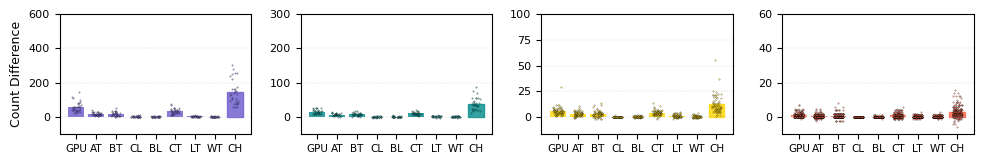

In [ ]:
# Plot the equipment and charger count differences between S2 and S1
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# Set the overall font and style
mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 11,
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.3,
    'grid.alpha': 0.3
})

# Combine all DataFrames
df = pd.concat([veh_cha_count_S2_S1_diff_large, veh_cha_count_S2_S1_diff_medium,
                veh_cha_count_S2_S1_diff_small, veh_cha_count_S2_S1_diff_nonhub], ignore_index=True)

gse_cols = [
    'GPU_counts', 'aircraft_tractor_counts', 'baggage_tractor_counts',
    'cargo_loader_counts', 'belt_loader_counts', 'cater_truck_counts',
    'lav_truck_counts', 'water_truck_counts'
]
charger_col = 'charger_count'
equipment_labels = gse_cols + ['Charger']
categories = ['Large Hub', 'Medium Hub', 'Small Hub', 'Non-Hub']

# Use more muted, professional colors
#colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
colors = ['slateblue', 'darkcyan', 'gold', 'tomato']

# Set x positions for the bars (one for each equipment type, including charger)
x = np.arange(len(equipment_labels))  # 9 equipment types
bar_width = 0.8  # Make the bar width wider (increased from 0.4)

# Create the subplots
fig, axes = plt.subplots(1, 4, figsize=(10, 1.8),sharey=False)
axes = axes.flatten()

# Iterate over categories and plot on corresponding axes
for i, cat in enumerate(categories):
    ax = axes[i]  # Get the appropriate axis for the current category
    print(i)

    # Bar plots for GSEs
    gse_vals = [df[df['category'] == cat][col].mean() for col in gse_cols]
    print(gse_vals)

    # Plot bars automatically with bar width and position adjustment
    ax.bar(x[:-1], gse_vals, width=bar_width, color=colors[i], label=cat, alpha=0.8, edgecolor='none')

    # Scatter plots for GSEs
    cat_df = df[df['category'] == cat]
    for j, col in enumerate(gse_cols):
        y_vals = cat_df[col].values
        x_base = x[j]  # We use x[j] directly as positions for GSE bars
        jitter = (np.random.rand(len(y_vals)) - 0.5) * bar_width * 0.6
        x_vals = np.full(len(y_vals), x_base) + jitter
        ax.scatter(x_vals, y_vals, color=colors[i], edgecolors='black', s=1, alpha=0.5, linewidths=0.3)

    # Bar plot for Charger (always at the last position)
    charger_val = df[df['category'] == cat][charger_col].mean()
    charger_bar = ax.bar(x[-1], charger_val, width=bar_width, color=colors[i], alpha=0.8, edgecolor=colors[i])

    # Scatter plots for Charger
    charger_vals = df[df['category'] == cat][charger_col].values
    jitter = (np.random.rand(len(charger_vals)) - 0.5) * bar_width * 0.6
    x_vals = np.full(len(charger_vals), x[-1]) + jitter
    ax.scatter(x_vals, charger_vals, color=colors[i], edgecolors='black', s=1, alpha=0.5, linewidths=0.3)

    # Aesthetics
    equip_list = ['GPU','Aircraft Tractor','Baggage Tractor','Cargo Loader','Belt Loader','Cater Truck','Lav Truck','Water Truck','Charger']
    equip_list_abb = ['GPU','AT','BT','CL','BL','CT','LT','WT','CH']
    ax.set_xticks(x)  # Now using the full range of x
    ax.set_xticklabels(equip_list_abb, rotation=0, ha='center', fontsize=7.5)  # Ensure center alignment
    axes[0].set_ylim(-100, 600)
    axes[1].set_ylim(-50, 300)
    axes[2].set_ylim(-16.6, 100)
    axes[3].set_ylim(-10, 60)
    # ax.set_xlabel(cat, fontsize=9)
    ax.spines['top'].set_visible(True)  # Enable top border
    ax.spines['right'].set_visible(True)  # Enable right border
    ax.spines['bottom'].set_visible(True)  # Enable bottom border
    ax.spines['left'].set_visible(True)  # Enable left border
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)  # Enable grid for each subplot
    # Set title for each subplot
    #ax.set_title(f'{cat} Equipment and Charger Counts')
    #ax.set_yscale('log')
    # Remove y-label for all but the first subplot
    if i != 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Count Difference')

    ax.tick_params(axis='y', left=True, labelleft=True, labelsize =8)
    # # Add legend for the first subplot only
    # if i == 0:
    #     ax.legend(
    #         title='Airport Category',
    #         loc='upper center',
    #         bbox_to_anchor=(0.5, 1.13),  # adjust position above the plot
    #         ncol=len(categories),        # one column per category
    #         frameon=False,
    #         title_fontsize=12,
    #         fontsize=10
    #     )

# Adjust spacing between subplots and increase bottom space for better x-labels
plt.subplots_adjust(wspace=0.3, bottom=0.25)  # Increased bottom space to avoid label overlap

# Increase font size for the y-ticks if necessary
plt.tight_layout()
plt.savefig("Figure5_b.pdf", format='pdf', bbox_inches='tight')
plt.show()


In [57]:
veh_cha_count_S3['GPU_counts'] = veh_cha_count_S3['GPU_counts_narrow'] + veh_cha_count_S3['GPU_counts_wide']
veh_cha_count_S3['aircraft_tractor_counts'] = veh_cha_count_S3['aircraft_tractor_counts_narrow'] + veh_cha_count_S3['aircraft_tractor_counts_wide']
veh_cha_count_S3['belt_loader_counts'] = veh_cha_count_S3['belt_loader_counts_narrow'] + veh_cha_count_S3['belt_loader_counts_wide']
veh_cha_count_S3['lav_truck_counts'] = veh_cha_count_S3['lav_truck_counts_narrow'] + veh_cha_count_S3['lav_truck_counts_wide']
veh_cha_count_S3['water_truck_counts'] = veh_cha_count_S3['water_truck_counts_narrow'] + veh_cha_count_S3['water_truck_counts_wide']
veh_cha_count_S3['cargo_loader_counts'] = veh_cha_count_S3['cargo_loader_counts_wide']

In [58]:
# Difference between S3 and S1
veh_cha_count_S3_S1_diff = veh_cha_count_S3.copy()
veh_cha_count_S3_S1_diff['GPU_counts'] = veh_cha_count_S3['GPU_counts'] - veh_cha_count_S1['GPU_counts']
veh_cha_count_S3_S1_diff['aircraft_tractor_counts'] = veh_cha_count_S3['aircraft_tractor_counts'] - veh_cha_count_S1['aircraft_tractor_counts']         
veh_cha_count_S3_S1_diff['baggage_tractor_counts'] = veh_cha_count_S3['baggage_tractor_counts'] - veh_cha_count_S1['baggage_tractor_counts']
veh_cha_count_S3_S1_diff['cargo_loader_counts'] = veh_cha_count_S3['cargo_loader_counts'] - veh_cha_count_S1['cargo_loader_counts']
veh_cha_count_S3_S1_diff['belt_loader_counts'] = veh_cha_count_S3['belt_loader_counts'] - veh_cha_count_S1['belt_loader_counts']
veh_cha_count_S3_S1_diff['cater_truck_counts'] = veh_cha_count_S3['cater_truck_counts'] - veh_cha_count_S1['cater_truck_counts']
veh_cha_count_S3_S1_diff['lav_truck_counts'] = veh_cha_count_S3['lav_truck_counts'] - veh_cha_count_S1['lav_truck_counts']
veh_cha_count_S3_S1_diff['water_truck_counts'] = veh_cha_count_S3['water_truck_counts'] - veh_cha_count_S1['water_truck_counts']  
veh_cha_count_S3_S1_diff['charger_count'] = veh_cha_count_S3['charger_count'] - veh_cha_count_S1['charger_count']   

In [59]:
veh_cha_count_S3_large = veh_cha_count_S3[veh_cha_count_S3['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
veh_cha_count_S3_large['category'] = 'Large Hub'
veh_cha_count_S3_medium = veh_cha_count_S3[veh_cha_count_S3['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
veh_cha_count_S3_medium['category'] = 'Medium Hub'
veh_cha_count_S3_small = veh_cha_count_S3[veh_cha_count_S3['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
veh_cha_count_S3_small['category'] = 'Small Hub'
veh_cha_count_S3_nonhub = veh_cha_count_S3[veh_cha_count_S3['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]
veh_cha_count_S3_nonhub['category'] = 'Non-Hub'

/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/520376927.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_cha_count_S3_large['category'] = 'Large Hub'
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/520376927.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_cha_count_S3_medium['category'] = 'Medium Hub'
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/520376927.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

In [60]:
veh_cha_count_S3_S1_diff_large = veh_cha_count_S3_S1_diff[veh_cha_count_S3_S1_diff['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
veh_cha_count_S3_S1_diff_large['category'] = 'Large Hub'
veh_cha_count_S3_S1_diff_medium = veh_cha_count_S3_S1_diff[veh_cha_count_S3_S1_diff['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
veh_cha_count_S3_S1_diff_medium['category'] = 'Medium Hub'
veh_cha_count_S3_S1_diff_small = veh_cha_count_S3_S1_diff[veh_cha_count_S3_S1_diff['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
veh_cha_count_S3_S1_diff_small['category'] = 'Small Hub'
veh_cha_count_S3_S1_diff_nonhub = veh_cha_count_S3_S1_diff[veh_cha_count_S3_S1_diff['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]
veh_cha_count_S3_S1_diff_nonhub['category'] = 'Non-Hub'

/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/1932588947.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_cha_count_S3_S1_diff_large['category'] = 'Large Hub'
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/1932588947.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_cha_count_S3_S1_diff_medium['category'] = 'Medium Hub'
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/1932588947.py:6: SettingWithCopyWarning: 
A value is trying to be set on a cop

0
[np.float64(-15.5), np.float64(-12.166666666666666), np.float64(-17.0), np.float64(-4.0), np.float64(-2.5), np.float64(-22.866666666666667), np.float64(-2.9), np.float64(-2.5)]
1
[np.float64(-9.833333333333334), np.float64(-8.266666666666667), np.float64(-9.833333333333334), np.float64(-1.2), np.float64(-0.5666666666666667), np.float64(-13.266666666666667), np.float64(-2.1666666666666665), np.float64(-1.1666666666666667)]
2
[np.float64(-5.7384615384615385), np.float64(-3.9846153846153847), np.float64(-4.446153846153846), np.float64(-0.09230769230769231), np.float64(-0.24615384615384617), np.float64(-6.707692307692308), np.float64(-0.8923076923076924), np.float64(-0.7692307692307693)]
3
[np.float64(-1.4427083333333333), np.float64(-0.9895833333333334), np.float64(-1.0364583333333333), np.float64(-0.010416666666666666), np.float64(-0.046875), np.float64(-1.3489583333333333), np.float64(-0.19270833333333334), np.float64(-0.11979166666666667)]


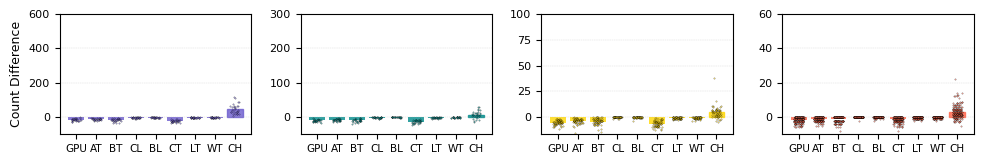

In [ ]:
# Plot the equipment and charger count differences between S3 and S1
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# Set the overall font and style
mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 11,
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.3,
    'grid.alpha': 0.3
})

# Combine all DataFrames
df = pd.concat([veh_cha_count_S3_S1_diff_large, veh_cha_count_S3_S1_diff_medium,
                veh_cha_count_S3_S1_diff_small, veh_cha_count_S3_S1_diff_nonhub], ignore_index=True)

gse_cols = [
    'GPU_counts', 'aircraft_tractor_counts', 'baggage_tractor_counts',
    'cargo_loader_counts', 'belt_loader_counts', 'cater_truck_counts',
    'lav_truck_counts', 'water_truck_counts'
]
charger_col = 'charger_count'
equipment_labels = gse_cols + ['Charger']
categories = ['Large Hub', 'Medium Hub', 'Small Hub', 'Non-Hub']

# Use more muted, professional colors
#colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
colors = ['slateblue', 'darkcyan', 'gold', 'tomato']

# Set x positions for the bars (one for each equipment type, including charger)
x = np.arange(len(equipment_labels))  # 9 equipment types
bar_width = 0.8  # Make the bar width wider (increased from 0.4)

# Create the subplots
fig, axes = plt.subplots(1, 4, figsize=(10, 1.8),sharey=False)
axes = axes.flatten()

# Iterate over categories and plot on corresponding axes
for i, cat in enumerate(categories):
    ax = axes[i]  # Get the appropriate axis for the current category
    print(i)

    # Bar plots for GSEs
    gse_vals = [df[df['category'] == cat][col].mean() for col in gse_cols]
    print(gse_vals)

    # Plot bars automatically with bar width and position adjustment
    ax.bar(x[:-1], gse_vals, width=bar_width, color=colors[i], label=cat, alpha=0.8, edgecolor='none')

    # Scatter plots for GSEs
    cat_df = df[df['category'] == cat]
    for j, col in enumerate(gse_cols):
        y_vals = cat_df[col].values
        x_base = x[j]  # We use x[j] directly as positions for GSE bars
        jitter = (np.random.rand(len(y_vals)) - 0.5) * bar_width * 0.6
        x_vals = np.full(len(y_vals), x_base) + jitter
        ax.scatter(x_vals, y_vals, color=colors[i], edgecolors='black', s=1, alpha=0.5, linewidths=0.3)

    # Bar plot for Charger (always at the last position)
    charger_val = df[df['category'] == cat][charger_col].mean()
    charger_bar = ax.bar(x[-1], charger_val, width=bar_width, color=colors[i], alpha=0.8, edgecolor=colors[i])

    # Scatter plots for Charger
    charger_vals = df[df['category'] == cat][charger_col].values
    jitter = (np.random.rand(len(charger_vals)) - 0.5) * bar_width * 0.6
    x_vals = np.full(len(charger_vals), x[-1]) + jitter
    ax.scatter(x_vals, charger_vals, color=colors[i], edgecolors='black', s=1, alpha=0.5, linewidths=0.3)

    # Aesthetics
    equip_list = ['GPU','Aircraft Tractor','Baggage Tractor','Cargo Loader','Belt Loader','Cater Truck','Lav Truck','Water Truck','Charger']
    equip_list_abb = ['GPU','AT','BT','CL','BL','CT','LT','WT','CH']
    ax.set_xticks(x)  # Now using the full range of x
    ax.set_xticklabels(equip_list_abb, rotation=0, ha='center', fontsize=7.5)  # Ensure center alignment
    axes[0].set_ylim(-100, 600)
    axes[1].set_ylim(-50, 300)
    axes[2].set_ylim(-16.6, 100)
    axes[3].set_ylim(-10, 60)
    # ax.set_xlabel(cat, fontsize=9)
    ax.spines['top'].set_visible(True)  # Enable top border
    ax.spines['right'].set_visible(True)  # Enable right border
    ax.spines['bottom'].set_visible(True)  # Enable bottom border
    ax.spines['left'].set_visible(True)  # Enable left border
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)  # Enable grid for each subplot

    # Set title for each subplot
    #ax.set_title(f'{cat} Equipment and Charger Counts')
    #ax.set_yscale('log')
    # Remove y-label for all but the first subplot

    ax.tick_params(axis='y', left=True, labelleft=True, labelsize =8)
    if i != 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Count Difference')
    # # Add legend for the first subplot only
    # if i == 0:
    #     ax.legend(
    #         title='Airport Category',
    #         loc='upper center',
    #         bbox_to_anchor=(0.5, 1.13),  # adjust position above the plot
    #         ncol=len(categories),        # one column per category
    #         frameon=False,
    #         title_fontsize=12,
    #         fontsize=10
    #     )

# Adjust spacing between subplots and increase bottom space for better x-labels
plt.subplots_adjust(wspace=0.3, bottom=0.25)  # Increased bottom space to avoid label overlap

# Increase font size for the y-ticks if necessary
plt.tight_layout()
plt.savefig("Figure5_c.pdf", format='pdf', bbox_inches='tight')
plt.show()


In [62]:
veh_cha_count_S4['GPU_counts'] = veh_cha_count_S4['GPU_counts_narrow'] + veh_cha_count_S4['GPU_counts_wide']
veh_cha_count_S4['aircraft_tractor_counts'] = veh_cha_count_S4['aircraft_tractor_counts_narrow'] + veh_cha_count_S4['aircraft_tractor_counts_wide']
veh_cha_count_S4['belt_loader_counts'] = veh_cha_count_S4['belt_loader_counts_narrow'] + veh_cha_count_S4['belt_loader_counts_wide']
veh_cha_count_S4['lav_truck_counts'] = veh_cha_count_S4['lav_truck_counts_narrow'] + veh_cha_count_S4['lav_truck_counts_wide']
veh_cha_count_S4['water_truck_counts'] = veh_cha_count_S4['water_truck_counts_narrow'] + veh_cha_count_S4['water_truck_counts_wide']
veh_cha_count_S4['cargo_loader_counts'] = veh_cha_count_S4['cargo_loader_counts_wide']

In [63]:
# Difference between S4 and S1
veh_cha_count_S4_S1_diff = veh_cha_count_S4.copy()
veh_cha_count_S4_S1_diff['GPU_counts'] = veh_cha_count_S4['GPU_counts'] - veh_cha_count_S1['GPU_counts']
veh_cha_count_S4_S1_diff['aircraft_tractor_counts'] = veh_cha_count_S4['aircraft_tractor_counts'] - veh_cha_count_S1['aircraft_tractor_counts']         
veh_cha_count_S4_S1_diff['baggage_tractor_counts'] = veh_cha_count_S4['baggage_tractor_counts'] - veh_cha_count_S1['baggage_tractor_counts']
veh_cha_count_S4_S1_diff['cargo_loader_counts'] = veh_cha_count_S4['cargo_loader_counts'] - veh_cha_count_S1['cargo_loader_counts']
veh_cha_count_S4_S1_diff['belt_loader_counts'] = veh_cha_count_S4['belt_loader_counts'] - veh_cha_count_S1['belt_loader_counts']
veh_cha_count_S4_S1_diff['cater_truck_counts'] = veh_cha_count_S4['cater_truck_counts'] - veh_cha_count_S1['cater_truck_counts']
veh_cha_count_S4_S1_diff['lav_truck_counts'] = veh_cha_count_S4['lav_truck_counts'] - veh_cha_count_S1['lav_truck_counts']  
veh_cha_count_S4_S1_diff['water_truck_counts'] = veh_cha_count_S4['water_truck_counts'] - veh_cha_count_S1['water_truck_counts']  
veh_cha_count_S4_S1_diff['charger_count'] = veh_cha_count_S4['charger_count'] - veh_cha_count_S1['charger_count']

In [64]:
veh_cha_count_S4_large = veh_cha_count_S4[veh_cha_count_S4['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
veh_cha_count_S4_large['category'] = 'Large Hub'
veh_cha_count_S4_medium = veh_cha_count_S4[veh_cha_count_S4['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
veh_cha_count_S4_medium['category'] = 'Medium Hub'
veh_cha_count_S4_small = veh_cha_count_S4[veh_cha_count_S4['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
veh_cha_count_S4_small['category'] = 'Small Hub'
veh_cha_count_S4_nonhub = veh_cha_count_S4[veh_cha_count_S4['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]
veh_cha_count_S4_nonhub['category'] = 'Non-Hub'

/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/336120556.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_cha_count_S4_large['category'] = 'Large Hub'
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/336120556.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_cha_count_S4_medium['category'] = 'Medium Hub'
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/336120556.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

In [65]:
veh_cha_count_S4_S1_diff_large = veh_cha_count_S4_S1_diff[veh_cha_count_S4_S1_diff['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
veh_cha_count_S4_S1_diff_large['category'] = 'Large Hub'
veh_cha_count_S4_S1_diff_medium = veh_cha_count_S4_S1_diff[veh_cha_count_S4_S1_diff['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
veh_cha_count_S4_S1_diff_medium['category'] = 'Medium Hub'
veh_cha_count_S4_S1_diff_small = veh_cha_count_S4_S1_diff[veh_cha_count_S4_S1_diff['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
veh_cha_count_S4_S1_diff_small['category'] = 'Small Hub'
veh_cha_count_S4_S1_diff_nonhub = veh_cha_count_S4_S1_diff[veh_cha_count_S4_S1_diff['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]
veh_cha_count_S4_S1_diff_nonhub['category'] = 'Non-Hub'

/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/495685449.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_cha_count_S4_S1_diff_large['category'] = 'Large Hub'
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/495685449.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_cha_count_S4_S1_diff_medium['category'] = 'Medium Hub'
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/495685449.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy o

0
[np.float64(39.96666666666667), np.float64(-0.1), np.float64(-10.0), np.float64(-1.6666666666666667), np.float64(-1.2), np.float64(-3.0), np.float64(-2.433333333333333), np.float64(-2.3)]
1
[np.float64(2.3666666666666667), np.float64(-6.0), np.float64(-8.633333333333333), np.float64(-1.1333333333333333), np.float64(-0.36666666666666664), np.float64(-10.0), np.float64(-2.1333333333333333), np.float64(-1.1666666666666667)]
2
[np.float64(-2.0615384615384613), np.float64(-3.6923076923076925), np.float64(-4.323076923076923), np.float64(-0.09230769230769231), np.float64(-0.24615384615384617), np.float64(-6.3538461538461535), np.float64(-0.8923076923076924), np.float64(-0.7692307692307693)]
3
[np.float64(-0.8645833333333334), np.float64(-0.9583333333333334), np.float64(-1.015625), np.float64(-0.010416666666666666), np.float64(-0.046875), np.float64(-1.3489583333333333), np.float64(-0.19270833333333334), np.float64(-0.11979166666666667)]


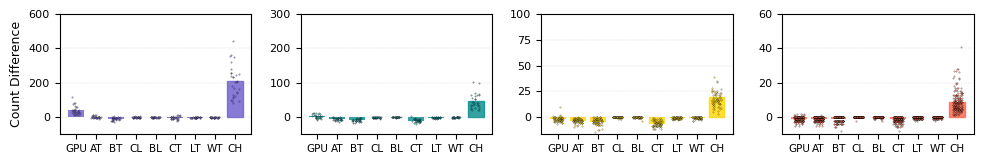

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# Set the overall font and style
mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 11,
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.3,
    'grid.alpha': 0.3
})

# Combine all DataFrames
df = pd.concat([veh_cha_count_S4_S1_diff_large, veh_cha_count_S4_S1_diff_medium,
                veh_cha_count_S4_S1_diff_small, veh_cha_count_S4_S1_diff_nonhub], ignore_index=True)

gse_cols = [
    'GPU_counts', 'aircraft_tractor_counts', 'baggage_tractor_counts',
    'cargo_loader_counts', 'belt_loader_counts', 'cater_truck_counts',
    'lav_truck_counts', 'water_truck_counts'
]
charger_col = 'charger_count'
equipment_labels = gse_cols + ['Charger']
categories = ['Large Hub', 'Medium Hub', 'Small Hub', 'Non-Hub']

# Use more muted, professional colors
#colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
colors = ['slateblue', 'darkcyan', 'gold', 'tomato']

# Set x positions for the bars (one for each equipment type, including charger)
x = np.arange(len(equipment_labels))  # 9 equipment types
bar_width = 0.8  # Make the bar width wider (increased from 0.4)

# Create the subplots
fig, axes = plt.subplots(1, 4, figsize=(10, 1.8),sharey=False)
axes = axes.flatten()

# Iterate over categories and plot on corresponding axes
for i, cat in enumerate(categories):
    ax = axes[i]  # Get the appropriate axis for the current category
    print(i)

    # Bar plots for GSEs
    gse_vals = [df[df['category'] == cat][col].mean() for col in gse_cols]
    print(gse_vals)

    # Plot bars automatically with bar width and position adjustment
    ax.bar(x[:-1], gse_vals, width=bar_width, color=colors[i], label=cat, alpha=0.8, edgecolor='none')

    # Scatter plots for GSEs
    cat_df = df[df['category'] == cat]
    for j, col in enumerate(gse_cols):
        y_vals = cat_df[col].values
        x_base = x[j]  # We use x[j] directly as positions for GSE bars
        jitter = (np.random.rand(len(y_vals)) - 0.5) * bar_width * 0.6
        x_vals = np.full(len(y_vals), x_base) + jitter
        ax.scatter(x_vals, y_vals, color=colors[i], edgecolors='black', s=1, alpha=0.5, linewidths=0.3)

    # Bar plot for Charger (always at the last position)
    charger_val = df[df['category'] == cat][charger_col].mean()
    charger_bar = ax.bar(x[-1], charger_val, width=bar_width, color=colors[i], alpha=0.8, edgecolor=colors[i])

    # Scatter plots for Charger
    charger_vals = df[df['category'] == cat][charger_col].values
    jitter = (np.random.rand(len(charger_vals)) - 0.5) * bar_width * 0.6
    x_vals = np.full(len(charger_vals), x[-1]) + jitter
    ax.scatter(x_vals, charger_vals, color=colors[i], edgecolors='black', s=1, alpha=0.5, linewidths=0.3)

    # Aesthetics
    equip_list = ['GPU','Aircraft Tractor','Baggage Tractor','Cargo Loader','Belt Loader','Cater Truck','Lav Truck','Water Truck','Charger']
    equip_list_abb = ['GPU','AT','BT','CL','BL','CT','LT','WT','CH']
    ax.set_xticks(x)  # Now using the full range of x
    ax.set_xticklabels(equip_list_abb, rotation=0, ha='center', fontsize=7.5)  # Ensure center alignment
    # ax.set_ylim(0, 1200)
    # ax.set_xlabel(cat, fontsize=9)
    ax.spines['top'].set_visible(True)  # Enable top border
    ax.spines['right'].set_visible(True)  # Enable right border
    ax.spines['bottom'].set_visible(True)  # Enable bottom border
    ax.spines['left'].set_visible(True)  # Enable left border
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)  # Enable grid for each subplot
    axes[0].set_ylim(-100, 600)
    axes[1].set_ylim(-50, 300)
    axes[2].set_ylim(-16.6, 100)
    axes[3].set_ylim(-10, 60)

    # Set title for each subplot
    #ax.set_title(f'{cat} Equipment and Charger Counts')
    #ax.set_yscale('log')
    # Remove y-label for all but the first subplot
    ax.tick_params(axis='y', left=True, labelleft=True, labelsize =8)
    if i != 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Count Difference')
    # # Add legend for the first subplot only
    # if i == 0:
    #     ax.legend(
    #         title='Airport Category',
    #         loc='upper center',
    #         bbox_to_anchor=(0.5, 1.13),  # adjust position above the plot
    #         ncol=len(categories),        # one column per category
    #         frameon=False,
    #         title_fontsize=12,
    #         fontsize=10
    #     )

# Adjust spacing between subplots and increase bottom space for better x-labels
plt.subplots_adjust(wspace=0.3, bottom=0.25)  # Increased bottom space to avoid label overlap

# Increase font size for the y-ticks if necessary
plt.tight_layout()
plt.savefig("Figure5_d.pdf", format='pdf', bbox_inches='tight')
plt.show()


In [67]:
veh_cha_count_S5['GPU_counts'] = veh_cha_count_S5['GPU_counts_narrow'] + veh_cha_count_S5['GPU_counts_wide']
veh_cha_count_S5['aircraft_tractor_counts'] = veh_cha_count_S5['aircraft_tractor_counts_narrow'] + veh_cha_count_S5['aircraft_tractor_counts_wide']
veh_cha_count_S5['belt_loader_counts'] = veh_cha_count_S5['belt_loader_counts_narrow'] + veh_cha_count_S5['belt_loader_counts_wide']
veh_cha_count_S5['lav_truck_counts'] = veh_cha_count_S5['lav_truck_counts_narrow'] + veh_cha_count_S5['lav_truck_counts_wide']
veh_cha_count_S5['water_truck_counts'] = veh_cha_count_S5['water_truck_counts_narrow'] + veh_cha_count_S5['water_truck_counts_wide']
veh_cha_count_S5['cargo_loader_counts'] = veh_cha_count_S5['cargo_loader_counts_wide']

In [68]:
# Difference between S5 and S1
veh_cha_count_S5_S1_diff = veh_cha_count_S5.copy()
veh_cha_count_S5_S1_diff['GPU_counts'] = veh_cha_count_S5['GPU_counts'] - veh_cha_count_S1['GPU_counts']
veh_cha_count_S5_S1_diff['aircraft_tractor_counts'] = veh_cha_count_S5['aircraft_tractor_counts'] - veh_cha_count_S1['aircraft_tractor_counts']         
veh_cha_count_S5_S1_diff['baggage_tractor_counts'] = veh_cha_count_S5['baggage_tractor_counts'] - veh_cha_count_S1['baggage_tractor_counts']
veh_cha_count_S5_S1_diff['cargo_loader_counts'] = veh_cha_count_S5['cargo_loader_counts'] - veh_cha_count_S1['cargo_loader_counts']
veh_cha_count_S5_S1_diff['belt_loader_counts'] = veh_cha_count_S5['belt_loader_counts'] - veh_cha_count_S1['belt_loader_counts']
veh_cha_count_S5_S1_diff['cater_truck_counts']  = veh_cha_count_S5['cater_truck_counts'] - veh_cha_count_S1['cater_truck_counts']
veh_cha_count_S5_S1_diff['lav_truck_counts'] = veh_cha_count_S5['lav_truck_counts'] - veh_cha_count_S1['lav_truck_counts']
veh_cha_count_S5_S1_diff['water_truck_counts'] = veh_cha_count_S5['water_truck_counts'] - veh_cha_count_S1['water_truck_counts']  
veh_cha_count_S5_S1_diff['charger_count'] = veh_cha_count_S5['charger_count'] - veh_cha_count_S1['charger_count']

In [69]:
veh_cha_count_S5_large = veh_cha_count_S5[veh_cha_count_S5['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
veh_cha_count_S5_large['category'] = 'Large Hub'
veh_cha_count_S5_medium = veh_cha_count_S5[veh_cha_count_S5['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
veh_cha_count_S5_medium['category'] = 'Medium Hub'
veh_cha_count_S5_small = veh_cha_count_S5[veh_cha_count_S5['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
veh_cha_count_S5_small['category'] = 'Small Hub'
veh_cha_count_S5_nonhub = veh_cha_count_S5[veh_cha_count_S5['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]
veh_cha_count_S5_nonhub['category'] = 'Non-Hub'

/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/1382150644.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_cha_count_S5_large['category'] = 'Large Hub'
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/1382150644.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_cha_count_S5_medium['category'] = 'Medium Hub'
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/1382150644.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

In [70]:
veh_cha_count_S5_S1_diff_large = veh_cha_count_S5_S1_diff[veh_cha_count_S5_S1_diff['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
veh_cha_count_S5_S1_diff_large['category'] = 'Large Hub'
veh_cha_count_S5_S1_diff_medium = veh_cha_count_S5_S1_diff[veh_cha_count_S5_S1_diff['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
veh_cha_count_S5_S1_diff_medium['category'] = 'Medium Hub'
veh_cha_count_S5_S1_diff_small = veh_cha_count_S5_S1_diff[veh_cha_count_S5_S1_diff['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
veh_cha_count_S5_S1_diff_small['category'] = 'Small Hub'
veh_cha_count_S5_S1_diff_nonhub = veh_cha_count_S5_S1_diff[veh_cha_count_S5_S1_diff['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]
veh_cha_count_S5_S1_diff_nonhub['category'] = 'Non-Hub'

/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/2343966245.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_cha_count_S5_S1_diff_large['category'] = 'Large Hub'
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/2343966245.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_cha_count_S5_S1_diff_medium['category'] = 'Medium Hub'
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/2343966245.py:6: SettingWithCopyWarning: 
A value is trying to be set on a cop

0
[np.float64(235.63333333333333), np.float64(140.6), np.float64(211.66666666666666), np.float64(28.333333333333332), np.float64(45.8), np.float64(54.93333333333333), np.float64(34.3), np.float64(22.733333333333334)]
1
[np.float64(59.06666666666667), np.float64(44.56666666666667), np.float64(62.63333333333333), np.float64(2.533333333333333), np.float64(10.3), np.float64(17.133333333333333), np.float64(15.633333333333333), np.float64(11.466666666666667)]
2
[np.float64(17.123076923076923), np.float64(15.184615384615384), np.float64(24.676923076923078), np.float64(0.24615384615384617), np.float64(3.7846153846153845), np.float64(6.323076923076923), np.float64(7.2153846153846155), np.float64(5.323076923076923)]
3
[np.float64(3.0625), np.float64(3.265625), np.float64(4.911458333333333), np.float64(0.0625), np.float64(0.625), np.float64(1.3125), np.float64(1.4427083333333333), np.float64(1.1666666666666667)]


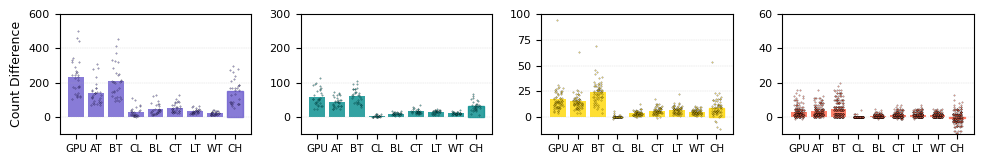

In [ ]:
# Plot the equipment and charger counts difference between Scenario 5 and Scenario 1
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# Set the overall font and style
mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 11,
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.3,
    'grid.alpha': 0.3
})

# Combine all DataFrames
df = pd.concat([veh_cha_count_S5_S1_diff_large, veh_cha_count_S5_S1_diff_medium,
                veh_cha_count_S5_S1_diff_small, veh_cha_count_S5_S1_diff_nonhub], ignore_index=True)

gse_cols = [
    'GPU_counts', 'aircraft_tractor_counts', 'baggage_tractor_counts',
    'cargo_loader_counts', 'belt_loader_counts', 'cater_truck_counts',
    'lav_truck_counts', 'water_truck_counts'
]
charger_col = 'charger_count'
equipment_labels = gse_cols + ['Charger']
categories = ['Large Hub', 'Medium Hub', 'Small Hub', 'Non-Hub']

# Use more muted, professional colors
#colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
colors = ['slateblue', 'darkcyan', 'gold', 'tomato']

# Set x positions for the bars (one for each equipment type, including charger)
x = np.arange(len(equipment_labels))  # 9 equipment types
bar_width = 0.8  # Make the bar width wider (increased from 0.4)

# Create the subplots
fig, axes = plt.subplots(1, 4, figsize=(10, 1.8),sharey=False)
axes = axes.flatten()

# Iterate over categories and plot on corresponding axes
for i, cat in enumerate(categories):
    ax = axes[i]  # Get the appropriate axis for the current category
    print(i)

    # Bar plots for GSEs
    gse_vals = [df[df['category'] == cat][col].mean() for col in gse_cols]
    print(gse_vals)

    # Plot bars automatically with bar width and position adjustment
    ax.bar(x[:-1], gse_vals, width=bar_width, color=colors[i], label=cat, alpha=0.8, edgecolor='none')

    # Scatter plots for GSEs
    cat_df = df[df['category'] == cat]
    for j, col in enumerate(gse_cols):
        y_vals = cat_df[col].values
        x_base = x[j]  # We use x[j] directly as positions for GSE bars
        jitter = (np.random.rand(len(y_vals)) - 0.5) * bar_width * 0.6
        x_vals = np.full(len(y_vals), x_base) + jitter
        ax.scatter(x_vals, y_vals, color=colors[i], edgecolors='black', s=1, alpha=0.5, linewidths=0.3)

    # Bar plot for Charger (always at the last position)
    charger_val = df[df['category'] == cat][charger_col].mean()
    charger_bar = ax.bar(x[-1], charger_val, width=bar_width, color=colors[i], alpha=0.8, edgecolor=colors[i])

    # Scatter plots for Charger
    charger_vals = df[df['category'] == cat][charger_col].values
    jitter = (np.random.rand(len(charger_vals)) - 0.5) * bar_width * 0.6
    x_vals = np.full(len(charger_vals), x[-1]) + jitter
    ax.scatter(x_vals, charger_vals, color=colors[i], edgecolors='black', s=1, alpha=0.5, linewidths=0.3)

    # Aesthetics
    equip_list = ['GPU','Aircraft Tractor','Baggage Tractor','Cargo Loader','Belt Loader','Cater Truck','Lav Truck','Water Truck','Charger']
    equip_list_abb = ['GPU','AT','BT','CL','BL','CT','LT','WT','CH']
    ax.set_xticks(x)  # Now using the full range of x
    ax.set_xticklabels(equip_list_abb, rotation=0, ha='center', fontsize=7.5)  # Ensure center alignment
    # ax.set_ylim(0, 1200)
    # ax.set_xlabel(cat, fontsize=9)
    ax.spines['top'].set_visible(True)  # Enable top border
    ax.spines['right'].set_visible(True)  # Enable right border
    ax.spines['bottom'].set_visible(True)  # Enable bottom border
    ax.spines['left'].set_visible(True)  # Enable left border
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)  # Enable grid for each subplot
    axes[0].set_ylim(-100, 600)
    axes[1].set_ylim(-50, 300)
    axes[2].set_ylim(-16.6, 100)
    axes[3].set_ylim(-10, 60)

    # Set title for each subplot
    #ax.set_title(f'{cat} Equipment and Charger Counts')
    #ax.set_yscale('log')
    # Remove y-label for all but the first subplot
    ax.tick_params(axis='y', left=True, labelleft=True, labelsize =8)
    if i != 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Count Difference')
    # # Add legend for the first subplot only
    # if i == 0:
    #     ax.legend(
    #         title='Airport Category',
    #         loc='upper center',
    #         bbox_to_anchor=(0.5, 1.13),  # adjust position above the plot
    #         ncol=len(categories),        # one column per category
    #         frameon=False,
    #         title_fontsize=12,
    #         fontsize=10
    #     )

# Adjust spacing between subplots and increase bottom space for better x-labels
plt.subplots_adjust(wspace=0.3, bottom=0.25)  # Increased bottom space to avoid label overlap

# Increase font size for the y-ticks if necessary
plt.tight_layout()
plt.savefig("Figure5_e.pdf", format='pdf', bbox_inches='tight')
plt.show()


In [72]:
veh_cha_count_S6['GPU_counts'] = veh_cha_count_S6['GPU_counts_narrow'] + veh_cha_count_S6['GPU_counts_wide']
veh_cha_count_S6['aircraft_tractor_counts'] = veh_cha_count_S6['aircraft_tractor_counts_narrow'] + veh_cha_count_S6['aircraft_tractor_counts_wide']
veh_cha_count_S6['belt_loader_counts'] = veh_cha_count_S6['belt_loader_counts_narrow'] + veh_cha_count_S6['belt_loader_counts_wide']
veh_cha_count_S6['lav_truck_counts'] = veh_cha_count_S6['lav_truck_counts_narrow'] + veh_cha_count_S6['lav_truck_counts_wide']
veh_cha_count_S6['water_truck_counts'] = veh_cha_count_S6['water_truck_counts_narrow'] + veh_cha_count_S6['water_truck_counts_wide']
veh_cha_count_S6['cargo_loader_counts'] = veh_cha_count_S6['cargo_loader_counts_wide']

In [73]:
# Difference between S6 and S1
veh_cha_count_S6_S1_diff = veh_cha_count_S6.copy()
veh_cha_count_S6_S1_diff['GPU_counts'] = veh_cha_count_S6['GPU_counts'] - veh_cha_count_S1['GPU_counts']
veh_cha_count_S6_S1_diff['aircraft_tractor_counts'] = veh_cha_count_S6['aircraft_tractor_counts'] - veh_cha_count_S1['aircraft_tractor_counts']         
veh_cha_count_S6_S1_diff['baggage_tractor_counts'] = veh_cha_count_S6['baggage_tractor_counts'] - veh_cha_count_S1['baggage_tractor_counts']
veh_cha_count_S6_S1_diff['cargo_loader_counts'] = veh_cha_count_S6['cargo_loader_counts'] - veh_cha_count_S1['cargo_loader_counts']
veh_cha_count_S6_S1_diff['belt_loader_counts'] = veh_cha_count_S6['belt_loader_counts'] - veh_cha_count_S1['belt_loader_counts']
veh_cha_count_S6_S1_diff['cater_truck_counts']  = veh_cha_count_S6['cater_truck_counts'] - veh_cha_count_S1['cater_truck_counts']
veh_cha_count_S6_S1_diff['lav_truck_counts'] = veh_cha_count_S6['lav_truck_counts'] - veh_cha_count_S1['lav_truck_counts']
veh_cha_count_S6_S1_diff['water_truck_counts'] = veh_cha_count_S6['water_truck_counts'] - veh_cha_count_S1['water_truck_counts']  
veh_cha_count_S6_S1_diff['charger_count'] = veh_cha_count_S6['charger_count'] - veh_cha_count_S1['charger_count']

In [74]:
veh_cha_count_S6_large = veh_cha_count_S6[veh_cha_count_S6['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
veh_cha_count_S6_large['category'] = 'Large Hub'
veh_cha_count_S6_medium = veh_cha_count_S6[veh_cha_count_S6['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
veh_cha_count_S6_medium['category'] = 'Medium Hub'
veh_cha_count_S6_small = veh_cha_count_S6[veh_cha_count_S6['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
veh_cha_count_S6_small['category'] = 'Small Hub'
veh_cha_count_S6_nonhub = veh_cha_count_S6[veh_cha_count_S6['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]
veh_cha_count_S6_nonhub['category'] = 'Non-Hub'

/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/756021145.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_cha_count_S6_large['category'] = 'Large Hub'
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/756021145.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_cha_count_S6_medium['category'] = 'Medium Hub'
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/756021145.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

In [75]:
veh_cha_count_S6_S1_diff_large = veh_cha_count_S6_S1_diff[veh_cha_count_S6_S1_diff['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
veh_cha_count_S6_S1_diff_large['category'] = 'Large Hub'
veh_cha_count_S6_S1_diff_medium = veh_cha_count_S6_S1_diff[veh_cha_count_S6_S1_diff['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
veh_cha_count_S6_S1_diff_medium['category'] = 'Medium Hub'
veh_cha_count_S6_S1_diff_small = veh_cha_count_S6_S1_diff[veh_cha_count_S6_S1_diff['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
veh_cha_count_S6_S1_diff_small['category'] = 'Small Hub'
veh_cha_count_S6_S1_diff_nonhub = veh_cha_count_S6_S1_diff[veh_cha_count_S6_S1_diff['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]
veh_cha_count_S6_S1_diff_nonhub['category'] = 'Non-Hub'

/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/2929002859.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_cha_count_S6_S1_diff_large['category'] = 'Large Hub'
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/2929002859.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  veh_cha_count_S6_S1_diff_medium['category'] = 'Medium Hub'
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/2929002859.py:6: SettingWithCopyWarning: 
A value is trying to be set on a cop

0
[np.float64(238.13333333333333), np.float64(152.5), np.float64(225.7), np.float64(29.066666666666666), np.float64(47.333333333333336), np.float64(59.3), np.float64(34.36666666666667), np.float64(23.333333333333332)]
1
[np.float64(59.6), np.float64(46.666666666666664), np.float64(66.1), np.float64(2.6), np.float64(10.333333333333334), np.float64(17.733333333333334), np.float64(15.866666666666667), np.float64(12.133333333333333)]
2
[np.float64(17.015384615384615), np.float64(16.015384615384615), np.float64(25.692307692307693), np.float64(0.24615384615384617), np.float64(3.876923076923077), np.float64(6.476923076923077), np.float64(7.369230769230769), np.float64(5.476923076923077)]
3
[np.float64(3.0677083333333335), np.float64(3.484375), np.float64(5.067708333333333), np.float64(0.0625), np.float64(0.65625), np.float64(1.3697916666666667), np.float64(1.4895833333333333), np.float64(1.203125)]


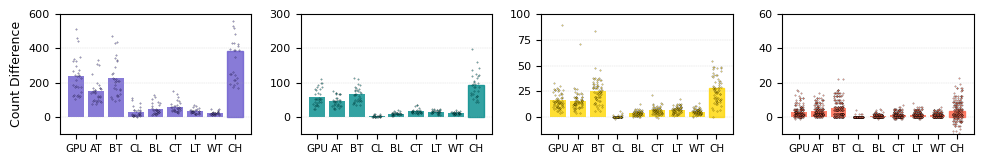

In [ ]:
# Plot the equipment and charger counts difference between Scenario 6 and Scenario 1
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# Set the overall font and style
mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 11,
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.3,
    'grid.alpha': 0.3
})

# Combine all DataFrames
df = pd.concat([veh_cha_count_S6_S1_diff_large, veh_cha_count_S6_S1_diff_medium,
                veh_cha_count_S6_S1_diff_small, veh_cha_count_S6_S1_diff_nonhub], ignore_index=True)

gse_cols = [
    'GPU_counts', 'aircraft_tractor_counts', 'baggage_tractor_counts',
    'cargo_loader_counts', 'belt_loader_counts', 'cater_truck_counts',
    'lav_truck_counts', 'water_truck_counts'
]
charger_col = 'charger_count'
equipment_labels = gse_cols + ['Charger']
categories = ['Large Hub', 'Medium Hub', 'Small Hub', 'Non-Hub']

# Use more muted, professional colors
#colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
colors = ['slateblue', 'darkcyan', 'gold', 'tomato']

# Set x positions for the bars (one for each equipment type, including charger)
x = np.arange(len(equipment_labels))  # 9 equipment types
bar_width = 0.8  # Make the bar width wider (increased from 0.4)

# Create the subplots
fig, axes = plt.subplots(1, 4, figsize=(10, 1.8),sharey=False)
axes = axes.flatten()

# Iterate over categories and plot on corresponding axes
for i, cat in enumerate(categories):
    ax = axes[i]  # Get the appropriate axis for the current category
    print(i)

    # Bar plots for GSEs
    gse_vals = [df[df['category'] == cat][col].mean() for col in gse_cols]
    print(gse_vals)

    # Plot bars automatically with bar width and position adjustment
    ax.bar(x[:-1], gse_vals, width=bar_width, color=colors[i], label=cat, alpha=0.8, edgecolor='none')

    # Scatter plots for GSEs
    cat_df = df[df['category'] == cat]
    for j, col in enumerate(gse_cols):
        y_vals = cat_df[col].values
        x_base = x[j]  # We use x[j] directly as positions for GSE bars
        jitter = (np.random.rand(len(y_vals)) - 0.5) * bar_width * 0.6
        x_vals = np.full(len(y_vals), x_base) + jitter
        ax.scatter(x_vals, y_vals, color=colors[i], edgecolors='black', s=1, alpha=0.5, linewidths=0.3)

    # Bar plot for Charger (always at the last position)
    charger_val = df[df['category'] == cat][charger_col].mean()
    charger_bar = ax.bar(x[-1], charger_val, width=bar_width, color=colors[i], alpha=0.8, edgecolor=colors[i])

    # Scatter plots for Charger
    charger_vals = df[df['category'] == cat][charger_col].values
    jitter = (np.random.rand(len(charger_vals)) - 0.5) * bar_width * 0.6
    x_vals = np.full(len(charger_vals), x[-1]) + jitter
    ax.scatter(x_vals, charger_vals, color=colors[i], edgecolors='black', s=1, alpha=0.5, linewidths=0.3)

    # Aesthetics
    equip_list = ['GPU','Aircraft Tractor','Baggage Tractor','Cargo Loader','Belt Loader','Cater Truck','Lav Truck','Water Truck','Charger']
    equip_list_abb = ['GPU','AT','BT','CL','BL','CT','LT','WT','CH']
    ax.set_xticks(x)  # Now using the full range of x
    ax.set_xticklabels(equip_list_abb, rotation=0, ha='center', fontsize=7.5)  # Ensure center alignment
    # ax.set_ylim(0, 1200)
    # ax.set_xlabel(cat, fontsize=10)
    ax.spines['top'].set_visible(True)  # Enable top border
    ax.spines['right'].set_visible(True)  # Enable right border
    ax.spines['bottom'].set_visible(True)  # Enable bottom border
    ax.spines['left'].set_visible(True)  # Enable left border
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)  # Enable grid for each subplot
    axes[0].set_ylim(-100, 600)
    axes[1].set_ylim(-50, 300)
    axes[2].set_ylim(-16.6, 100)
    axes[3].set_ylim(-10, 60)

    # Set title for each subplot
    #ax.set_title(f'{cat} Equipment and Charger Counts')
    #ax.set_yscale('log')
    # Remove y-label for all but the first subplot
    ax.tick_params(axis='y', left=True, labelleft=True, labelsize =8)
    if i != 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Count Difference')
    # # Add legend for the first subplot only
    # if i == 0:
    #     ax.legend(
    #         title='Airport Category',
    #         loc='upper center',
    #         bbox_to_anchor=(0.5, 1.13),  # adjust position above the plot
    #         ncol=len(categories),        # one column per category
    #         frameon=False,
    #         title_fontsize=12,
    #         fontsize=10
    #     )

# Adjust spacing between subplots and increase bottom space for better x-labels
plt.subplots_adjust(wspace=0.3, bottom=0.25)  # Increased bottom space to avoid label overlap

# Increase font size for the y-ticks if necessary
plt.tight_layout()
plt.savefig("Figure5_f.pdf", format='pdf', bbox_inches='tight')
plt.show()


### Table 1

In [61]:
# # get energy consumption for all the airports
# import glob
# folder_path = Path('./all_flight_GSE_tasks')
# GSE_tasks = glob.glob(os.path.join(folder_path, '*.csv'))
# for file_path in GSE_tasks:
#     df_temp = pd.read_csv(file_path, parse_dates=['start_time', 'end_time'])
#     df_temp['start_time'] = pd.to_datetime(df_temp['start_time'])
#     df_temp['date'] = df_temp['start_time'].dt.date
#     enery_day = df_temp.groupby('date').agg({'energy_consumption': 'sum'}).reset_index()
#     airport = os.path.basename(file_path).split('_')[0]
#     enery_day.to_csv(f'./all_flight_energy_consumption/{airport}_daily_GSE_energy.csv')

In [93]:
folder_path = Path('./all_flight_energy_consumption')
energy_consumption = glob.glob(os.path.join(folder_path, '*.csv'))

airport_list = []
annual_energy_list = []
avg_daily_energy_list = []
for file_path in energy_consumption:
    df_temp = pd.read_csv(file_path)
    airport = os.path.basename(file_path).split('_')[0]
    annual_energy = df_temp['energy_consumption'].sum()
    avg_daily_energy = df_temp['energy_consumption'].mean()
    airport_list.append(airport)
    annual_energy_list.append(annual_energy)
    avg_daily_energy_list.append(avg_daily_energy)

energy_df = pd.DataFrame({'airport':airport_list, 'annual_energy': annual_energy_list, 'avg_daily_energy': avg_daily_energy_list})

In [95]:
energy_df_317 = energy_df[energy_df['airport'].isin(annual_flight_count_mainland_FAA['airport'].to_list())]

In [96]:
energy_df_317_large = energy_df_317[energy_df_317['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
energy_df_317_medium = energy_df_317[energy_df_317['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
energy_df_317_small = energy_df_317[energy_df_317['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
energy_df_317_nonhub = energy_df_317[energy_df_317['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]

In [176]:
energy_df_317_large['annual_energy'].max()

np.float64(50877596.89258334)

In [177]:
energy_df_317_large['annual_energy'].min()

np.float64(10818860.254250001)

In [178]:
energy_df_317_large['annual_energy'].mean()

np.float64(26709038.806311116)

In [179]:
energy_df_317_medium['annual_energy'].max()

np.float64(12102075.0125)

In [180]:
energy_df_317_medium['annual_energy'].min()

np.float64(2940516.6373333335)

In [181]:
energy_df_317_medium['annual_energy'].mean()

np.float64(5934429.712575)

In [182]:
energy_df_317_small['annual_energy'].max()

np.float64(9238625.38725)

In [183]:
energy_df_317_small['annual_energy'].min()

np.float64(577366.4779166667)

In [184]:
energy_df_317_small['annual_energy'].mean()

np.float64(1617352.5571858974)

In [185]:
energy_df_317_nonhub['annual_energy'].max()

np.float64(1204434.393416667)

In [186]:
energy_df_317_nonhub['annual_energy'].min()

np.float64(8056.790083333333)

In [187]:
energy_df_317_nonhub['annual_energy'].mean()

np.float64(265419.14039930556)

In [188]:
energy_df_317_large['avg_daily_energy'].max()

np.float64(138631.05420322437)

In [189]:
energy_df_317_large['avg_daily_energy'].min()

np.float64(29479.1832540872)

In [190]:
energy_df_317_large['avg_daily_energy'].mean()

np.float64(72776.67249676051)

In [191]:
energy_df_317_medium['avg_daily_energy'].max()

np.float64(33065.77872267759)

In [192]:
energy_df_317_medium['avg_daily_energy'].min()

np.float64(8034.198462659381)

In [193]:
energy_df_317_medium['avg_daily_energy'].mean()

np.float64(16182.448970606825)

In [194]:
energy_df_317_small['avg_daily_energy'].max()

np.float64(25173.366177792916)

In [195]:
energy_df_317_small['avg_daily_energy'].min()

np.float64(1581.8259668949772)

In [196]:
energy_df_317_small['avg_daily_energy'].mean()

np.float64(4443.381513228176)

In [197]:
energy_df_317_nonhub['avg_daily_energy'].max()

np.float64(4040.1181739130434)

In [198]:
energy_df_317_nonhub['avg_daily_energy'].min()

np.float64(116.96748333333333)

In [199]:
energy_df_317_nonhub['avg_daily_energy'].mean()

np.float64(766.3451743166273)

### Supplementary Figure 1a

In [91]:
# # get energy consumption for all the airports
# import glob
# folder_path = Path('./all_flight_GSE_tasks')
# GSE_tasks = glob.glob(os.path.join(folder_path, '*.csv'))
# for file_path in GSE_tasks:
#     df_temp = pd.read_csv(file_path, parse_dates=['start_time', 'end_time'])
#     df_temp['start_time'] = pd.to_datetime(df_temp['start_time'])
#     df_temp['date'] = df_temp['start_time'].dt.date
#     enery_day = df_temp.groupby(['date', 'GSE_type']).agg({'energy_consumption': 'sum'}).reset_index()
#     avg_energy_day = enery_day.groupby('GSE_type').agg({'energy_consumption': 'mean'}).reset_index()
#     airport = os.path.basename(file_path).split('_')[0]
#     avg_energy_day.to_csv(f'./all_flight_energy_consumption/avg_daily_energy_consumption_breakdown/{airport}_daily_GSE_energy.csv')

In [97]:
airport_list = ['ATL', 'DEN', 'DFW', 'ORD', 'LAX', 'SFO', 'SEA', 'JFK', 'CLT', 'EWR', 'MEM', 'PDX', \
                'DAL', 'CVG', 'STL', 'OAK', 'HOU', 'RDU', 'MCI', 'CLE', 'SDF', 'GEG', 'OKC', 'ORF', \
                'BUF', 'ELP', 'MYR', 'TYS', 'CAE', 'GRR', 'BIL', 'RFD', 'TLH', 'FWA', 'ROA', 'AZA', 'SHV', 'ABE', 'SBN', 'ASE']
folder_path = Path('./all_flight_energy_consumption/avg_daily_energy_consumption_breakdown')
GSE_avg_energy_day = glob.glob(os.path.join(folder_path, '*.csv'))
GSE_avg_energy_day_list = []
for file_path in GSE_avg_energy_day:
    airport = os.path.basename(file_path).split('_')[0]
    if airport in airport_list:
        df_temp = pd.read_csv(file_path)
        df_temp['airport'] = airport
        # print(airport)
        GSE_avg_energy_day_list.append(df_temp)
GSE_avg_energy_day_df = pd.concat(GSE_avg_energy_day_list)

In [99]:
GSE_avg_energy_day_df['energy_consumption_MWh'] = GSE_avg_energy_day_df['energy_consumption']/1000

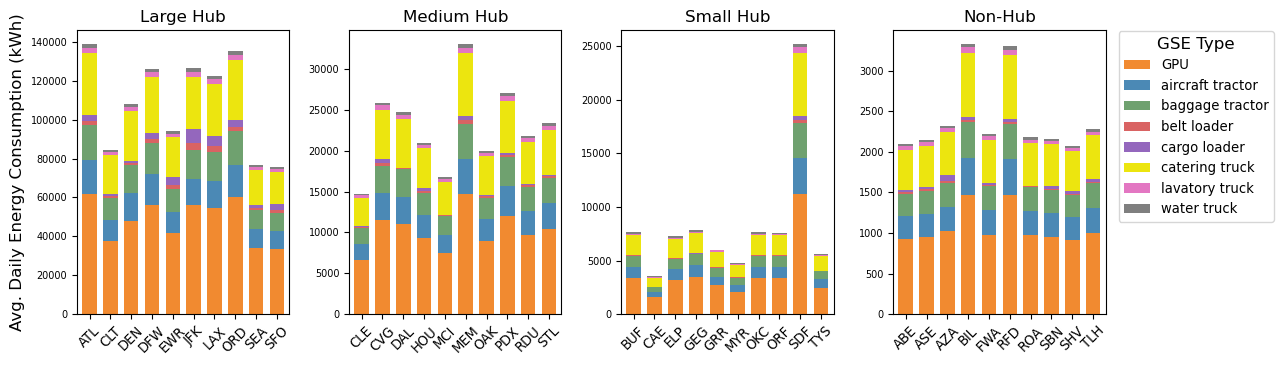

In [364]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace this with your actual DataFrame
df = GSE_avg_energy_day_df.copy()

# Grouped airports by category
grouped_airports = {
    'Large Hub': ['ATL', 'DEN', 'DFW', 'ORD', 'LAX', 'SFO', 'SEA', 'JFK', 'CLT', 'EWR'],
    'Medium Hub': ['MEM', 'PDX', 'DAL', 'CVG', 'STL', 'OAK', 'HOU', 'RDU', 'MCI', 'CLE'],
    'Small Hub': ['SDF', 'GEG', 'OKC', 'ORF', 'BUF', 'ELP', 'MYR', 'TYS', 'CAE', 'GRR'],
    'Non-Hub': ['BIL', 'RFD', 'TLH', 'FWA', 'ROA', 'AZA', 'SHV', 'ABE', 'SBN', 'ASE']
}

gse_colors = {
    'GPU': "#f18a30",
    'aircraft tractor': "#4B89B5",
    'baggage tractor': "#6FA16F",
    'belt loader': "#d96363",
    'cargo loader': '#9467bd',
    'catering truck': "#ece50f",
    'lavatory truck': '#e377c2',
    'water truck': '#7f7f7f'
}  # enough unique colors for GSE types

# Remove `sharey=True` to allow independent y-axis scaling
fig, axes = plt.subplots(1, 4, figsize=(13, 4))  
axes = axes.flatten()

for i, (category, airports) in enumerate(grouped_airports.items()):
    df_subset = df[df['airport'].isin(airports)]

    # Pivot to get airports on x-axis and GSE types as columns
    pivot_df = df_subset.pivot_table(index='airport', columns='GSE_type', values='energy_consumption', aggfunc='sum').fillna(0)

    colors_for_plot = [gse_colors.get(gse, '#cccccc') for gse in pivot_df.columns]

    # Plot stacked bar chart
    pivot_df.plot(kind='bar', stacked=True, ax=axes[i], color=colors_for_plot, width=0.7, legend=(i == 3))

    axes[i].set_xlabel(' ')
    axes[i].tick_params(axis='x', rotation=45, labelsize=9.5)
    
    if i == 0:
        axes[i].set_ylabel('Avg. Daily Energy Consumption (kWh)', fontsize=12)
    else:
        axes[i].set_ylabel('')
        axes[i].tick_params(axis='y', left=True, labelleft=True)  # keep y-ticks for all subplots now

    axes[i].set_title(category, fontsize=12)

# Only add legend to last subplot
if 'GSE_type' in df.columns:
    handles, labels = axes[3].get_legend_handles_labels()
    axes[3].legend(handles, labels, bbox_to_anchor=(1.03, 1.02), loc='upper left', fontsize=9.5, title="GSE Type")

plt.tight_layout()
plt.show()

### Figure 4a

In [65]:
load_profiles_S1_path = Path('./all_flight_load_profiles/S1_SOC_insufficient_40')
load_profiles_S2_path = Path('./all_flight_load_profiles/S2_SOC_insufficient_20')
load_profiles_S3_path = Path('./all_flight_load_profiles/S3_charge_during_service_gaps_40')
load_profiles_S4_path = Path('./all_flight_load_profiles/S4_charge_during_service_gaps_20')
load_profiles_S5_path = Path('./all_flight_load_profiles/S5_charge_overnight_40')
load_profiles_S6_path = Path('./all_flight_load_profiles/S6_charge_overnight_20')

In [66]:
# Get peak demand for each airport in scenario 1
load_S1 = glob.glob(os.path.join(load_profiles_S1_path, '*.csv'))

airport_list = []
peak_demand_list = []

for file_path in load_S1:
    df_temp = pd.read_csv(file_path)
    airport = os.path.basename(file_path).split('_')[0]
    peak_demand = df_temp['power'].max()
    airport_list.append(airport)
    peak_demand_list.append(peak_demand)

peak_demand_df_S1 = pd.DataFrame({'airport':airport_list, 'peak_demand': peak_demand_list})

In [67]:
peak_demand_df_S1['peak_demand'].max()

np.int64(15760)

In [68]:
us_airports_gps = pd.read_csv('./us_airports_gps.csv')
us_airports_gps = us_airports_gps.dropna(subset='iata_code')

In [69]:
peak_demand_df_S1_location = pd.merge(peak_demand_df_S1, us_airports_gps[['iata_code', 'latitude_deg', 'longitude_deg', 'region_name']], left_on='airport', right_on='iata_code', how='inner')

In [70]:
import geopandas as gpd
from shapely.geometry import Point
peak_demand_df_S1_location['geometry'] = peak_demand_df_S1_location.apply(lambda row: Point(row['longitude_deg'], row['latitude_deg']), axis=1)
peak_demand_df_S1_location_gdf = gpd.GeoDataFrame(peak_demand_df_S1_location, geometry='geometry', crs='EPSG:4326')

In [71]:
peak_demand_df_S1_large = peak_demand_df_S1_location_gdf[peak_demand_df_S1_location_gdf['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
peak_demand_df_S1_medium = peak_demand_df_S1_location_gdf[peak_demand_df_S1_location_gdf['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
peak_demand_df_S1_small= peak_demand_df_S1_location_gdf[peak_demand_df_S1_location_gdf['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
peak_demand_df_S1_nonhub = peak_demand_df_S1_location_gdf[peak_demand_df_S1_location_gdf['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]

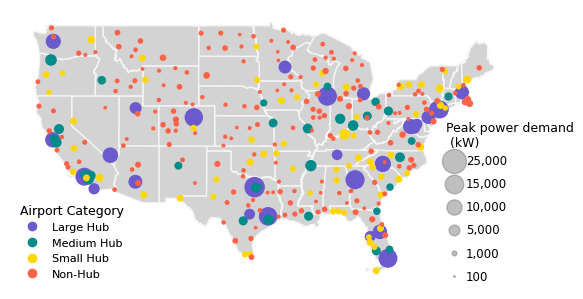

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.lines import Line2D

# Set up plot
fig, ax = plt.subplots(figsize=(6, 4))

# Normalize size
max_size = 25000
scale_factor = 300
normalize_size = lambda x: (x / max_size) * scale_factor

# Plot base map
us_mainland.plot(ax=ax, color='lightgrey', edgecolor='whitesmoke')

# Plot airport categories
peak_demand_df_S1_large.plot(ax=ax, markersize=normalize_size(peak_demand_df_S1_large['peak_demand']), color='slateblue', label='Large Hub')
peak_demand_df_S1_medium.plot(ax=ax, markersize=normalize_size(peak_demand_df_S1_medium['peak_demand']), color='darkcyan', label='Medium Hub')
peak_demand_df_S1_small.plot(ax=ax, markersize=normalize_size(peak_demand_df_S1_small['peak_demand']), color='gold', label='Small Hub')
peak_demand_df_S1_nonhub.plot(ax=ax, markersize=normalize_size(peak_demand_df_S1_nonhub['peak_demand']), color='tomato', label='Non-Hub')

# Custom legend for color (category)
color_legend = [
    Line2D([0], [0], marker='o', color='w', label='Large Hub', markerfacecolor='slateblue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Medium Hub', markerfacecolor='darkcyan', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Small Hub', markerfacecolor='gold', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Non-Hub', markerfacecolor='tomato', markersize=8)
]
legend1 = ax.legend(handles=color_legend, title='Airport Category', loc = 'lower left', fontsize=8, title_fontsize=9)
ax.add_artist(legend1)
legend1.get_frame().set_linewidth(0)

# Custom size scale (marker size)
example_counts = [100, 1000, 5000, 10000, 15000, 25000]  # adjust as needed
x_pos, y_pos = -125, 24  # adjust position to fit map
for i, count in enumerate(example_counts):
    y = y_pos + i * 2.3
    size = normalize_size(count)
    ax.scatter(x_pos+53, y, s=size, color='gray', alpha=0.5)
    ax.text(x_pos + 54.5, y, f'{count:,}', va='center', fontsize=8.5)

ax.text(x_pos+52, y_pos + len(example_counts)*2+1, 'Peak power demand\n (kW)', fontsize=9)

# Remove border and axes
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Figure4_a.pdf", format='pdf', bbox_inches='tight')
plt.show()

### Figure 4b

In [73]:
# Get peak demand for each airport in scenario 2
load_S2 = glob.glob(os.path.join(load_profiles_S2_path, '*.csv'))

airport_list = []
peak_demand_list = []

for file_path in load_S2:
    df_temp = pd.read_csv(file_path)
    airport = os.path.basename(file_path).split('_')[0]
    peak_demand = df_temp['power'].max()
    airport_list.append(airport)
    peak_demand_list.append(peak_demand)

peak_demand_df_S2 = pd.DataFrame({'airport':airport_list, 'peak_demand': peak_demand_list})

In [74]:
peak_demand_df_S2_location = pd.merge(peak_demand_df_S2, us_airports_gps[['iata_code', 'latitude_deg', 'longitude_deg', 'region_name']], left_on='airport', right_on='iata_code', how='inner')
peak_demand_df_S2_location['geometry'] = peak_demand_df_S2_location.apply(lambda row: Point(row['longitude_deg'], row['latitude_deg']), axis=1)
peak_demand_df_S2_location_gdf = gpd.GeoDataFrame(peak_demand_df_S2_location, geometry='geometry', crs='EPSG:4326')

In [75]:
peak_demand_df_S1_location_gdf

,airport,peak_demand,iata_code,latitude_deg,longitude_deg,region_name,geometry
0,JAN,760,JAN,32.311199,-90.075897,Mississippi,POINT (-90.0759 32.3112)
1,SNA,3520,SNA,33.675701,-117.867996,California,POINT (-117.868 33.6757)
2,AVL,1240,AVL,35.436199,-82.541801,North Carolina,POINT (-82.5418 35.4362)
3,DEC,360,DEC,39.834598541259766,-88.8656997680664,Illinois,POINT (-88.8657 39.8346)
4,CIU,320,CIU,46.247707,-84.471379,Michigan,POINT (-84.47138 46.24771)
...,...,...,...,...,...,...,...
337,COD,360,COD,44.520199,-109.024002,Wyoming,POINT (-109.024 44.5202)
338,GGG,280,GGG,32.38399887084961,-94.71150207519531,Texas,POINT (-94.7115 32.384)
339,TYR,280,TYR,32.35409927368164,-95.40239715576172,Texas,POINT (-95.4024 32.3541)
340,PAE,600,PAE,47.9063,-122.281998,Washington,POINT (-122.282 47.9063)


In [76]:
peak_demand_df_S2_location_gdf

,airport,peak_demand,iata_code,latitude_deg,longitude_deg,region_name,geometry
0,JAN,540,JAN,32.311199,-90.075897,Mississippi,POINT (-90.0759 32.3112)
1,SNA,2900,SNA,33.675701,-117.867996,California,POINT (-117.868 33.6757)
2,AVL,660,AVL,35.436199,-82.541801,North Carolina,POINT (-82.5418 35.4362)
3,DEC,180,DEC,39.834598541259766,-88.8656997680664,Illinois,POINT (-88.8657 39.8346)
4,CIU,180,CIU,46.247707,-84.471379,Michigan,POINT (-84.47138 46.24771)
...,...,...,...,...,...,...,...
337,COD,180,COD,44.520199,-109.024002,Wyoming,POINT (-109.024 44.5202)
338,GGG,140,GGG,32.38399887084961,-94.71150207519531,Texas,POINT (-94.7115 32.384)
339,TYR,220,TYR,32.35409927368164,-95.40239715576172,Texas,POINT (-95.4024 32.3541)
340,PAE,420,PAE,47.9063,-122.281998,Washington,POINT (-122.282 47.9063)


In [77]:
# Calculate the difference in peak demand between Scenario 2 and Scenario 1
peak_demand_df_S2_S1_diff_location_gdf = peak_demand_df_S2_location_gdf.merge(
    peak_demand_df_S1_location_gdf[['airport', 'peak_demand']],
    on='airport',
    suffixes=('_S2', '_S1')
)
peak_demand_df_S2_S1_diff_location_gdf['peak_demand_diff'] = peak_demand_df_S2_S1_diff_location_gdf['peak_demand_S2'] - peak_demand_df_S2_S1_diff_location_gdf['peak_demand_S1']

In [78]:
peak_demand_df_S2_large = peak_demand_df_S2_location_gdf[peak_demand_df_S2_location_gdf['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
peak_demand_df_S2_medium = peak_demand_df_S2_location_gdf[peak_demand_df_S2_location_gdf['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
peak_demand_df_S2_small= peak_demand_df_S2_location_gdf[peak_demand_df_S2_location_gdf['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
peak_demand_df_S2_nonhub = peak_demand_df_S2_location_gdf[peak_demand_df_S2_location_gdf['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]

In [79]:
peak_demand_df_S2_S1_diff_large = peak_demand_df_S2_S1_diff_location_gdf[peak_demand_df_S2_S1_diff_location_gdf['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
peak_demand_df_S2_S1_diff_medium = peak_demand_df_S2_S1_diff_location_gdf[peak_demand_df_S2_S1_diff_location_gdf['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
peak_demand_df_S2_S1_diff_small= peak_demand_df_S2_S1_diff_location_gdf[peak_demand_df_S2_S1_diff_location_gdf['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
peak_demand_df_S2_S1_diff_nonhub = peak_demand_df_S2_S1_diff_location_gdf[peak_demand_df_S2_S1_diff_location_gdf['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]

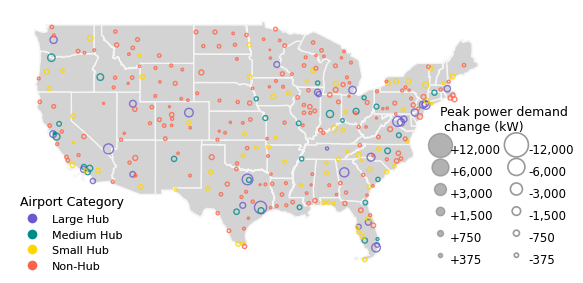

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------------------
# Plot setup
# -------------------------------
fig, ax = plt.subplots(figsize=(6, 4))

# Marker size normalization (magnitude only)
max_size = 12000
scale_factor = 300
normalize_size = lambda x: (abs(x) / max_size) * scale_factor

# Base map
us_mainland.plot(ax=ax, color='lightgrey', edgecolor='whitesmoke')

# -------------------------------
# Helper function for categories
# -------------------------------
def plot_category(df, color, label):
    # Positive values → filled circles
    pos = df[df['peak_demand_diff'] > 0]
    ax.scatter(
        pos.geometry.x,
        pos.geometry.y,
        s=normalize_size(pos['peak_demand_diff']),
        color=color,
        edgecolors=color,
        alpha=0.8,
        label=label
    )

    # Negative values → hollow circles
    neg = df[df['peak_demand_diff'] < 0]
    ax.scatter(
        neg.geometry.x,
        neg.geometry.y,
        s=normalize_size(neg['peak_demand_diff']),
        facecolors='none',
        edgecolors=color,
        linewidths=1,
        alpha=0.8
    )

# -------------------------------
# Plot airport categories
# -------------------------------
plot_category(peak_demand_df_S2_S1_diff_large,  'slateblue', 'Large Hub')
plot_category(peak_demand_df_S2_S1_diff_medium, 'darkcyan',  'Medium Hub')
plot_category(peak_demand_df_S2_S1_diff_small,  'gold',      'Small Hub')
plot_category(peak_demand_df_S2_S1_diff_nonhub, 'tomato',    'Non-Hub')

# -------------------------------
# Legend: Airport category (color)
# -------------------------------
color_legend = [
    Line2D([0], [0], marker='o', color='w', label='Large Hub',
           markerfacecolor='slateblue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Medium Hub',
           markerfacecolor='darkcyan', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Small Hub',
           markerfacecolor='gold', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Non-Hub',
           markerfacecolor='tomato', markersize=8)
]

legend1 = ax.legend(
    handles=color_legend,
    title='Airport Category',
    loc='lower left',
    bbox_to_anchor=(0, -0.03),
    fontsize=8,
    title_fontsize=9
)
ax.add_artist(legend1)
legend1.get_frame().set_linewidth(0)

# -------------------------------
# Legend: Sign (filled vs hollow)
# -------------------------------
sign_legend = [
    Line2D([0], [0], marker='o', color='black',
           label='Increase',
           markerfacecolor='black', markersize=8),
    Line2D([0], [0], marker='o', color='black',
           label='Decrease',
           markerfacecolor='none', markersize=8)
]

# -------------------------------
# Size legend (magnitude)
# -------------------------------
example_counts = [375, 750, 1500, 3000, 6000,12000]
x_pos, y_pos = -72, 25
dy = 2.3

for i, count in enumerate(example_counts):
    y = y_pos + i * dy

    # Positive (filled)
    ax.scatter(
        x_pos,
        y,
        s=normalize_size(count),
        color='gray',
        alpha=0.6
    )
    ax.text(x_pos + 1.3, y-0.5, f'+{count:,}', va='center', fontsize=8.5)

    # Negative (hollow)
    ax.scatter(
        x_pos + 10,
        y,
        s=normalize_size(count),
        facecolors='none',
        edgecolors='gray',
        linewidths=1.2,
        alpha=0.8
    )
    ax.text(x_pos + 11.5, y-0.5, f'-{count:,}', va='center', fontsize=8.5)

# Legend title
ax.text(x_pos, y_pos + len(example_counts)*2+1, 'Peak power demand\n change (kW)', fontsize=9)
# -------------------------------
# Final cleanup
# -------------------------------
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Figure4_b.pdf", format='pdf', bbox_inches='tight')
plt.show()


In [82]:
peak_demand_df_S2_S1_diff_large['peak_demand_diff'].min()

np.int64(-3060)

### Figure 4c

In [83]:
# Get peak demand for each airport in scenario 3
load_S3 = glob.glob(os.path.join(load_profiles_S3_path, '*.csv'))

airport_list = []
peak_demand_list = []

for file_path in load_S3:
    df_temp = pd.read_csv(file_path)
    airport = os.path.basename(file_path).split('_')[0]
    peak_demand = df_temp['power'].max()
    airport_list.append(airport)
    peak_demand_list.append(peak_demand)

peak_demand_df_S3 = pd.DataFrame({'airport':airport_list, 'peak_demand': peak_demand_list})

In [84]:
peak_demand_df_S3_location = pd.merge(peak_demand_df_S3, us_airports_gps[['iata_code', 'latitude_deg', 'longitude_deg', 'region_name']], left_on='airport', right_on='iata_code', how='inner')
peak_demand_df_S3_location['geometry'] = peak_demand_df_S3_location.apply(lambda row: Point(row['longitude_deg'], row['latitude_deg']), axis=1)
peak_demand_df_S3_location_gdf = gpd.GeoDataFrame(peak_demand_df_S3_location, geometry='geometry', crs='EPSG:4326')

In [85]:
# Calculate the difference in peak demand between Scenario 3 and Scenario 1
peak_demand_df_S3_S1_diff_location_gdf = peak_demand_df_S3_location_gdf.merge(
    peak_demand_df_S1_location_gdf[['airport', 'peak_demand']],
    on='airport',
    suffixes=('_S3', '_S1')
)
peak_demand_df_S3_S1_diff_location_gdf['peak_demand_diff'] = peak_demand_df_S3_S1_diff_location_gdf['peak_demand_S3'] - peak_demand_df_S3_S1_diff_location_gdf['peak_demand_S1']

In [86]:
peak_demand_df_S3_location_gdf['peak_demand'].max()

np.int64(18400)

In [87]:
peak_demand_df_S3_large = peak_demand_df_S3_location_gdf[peak_demand_df_S3_location_gdf['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
peak_demand_df_S3_medium = peak_demand_df_S3_location_gdf[peak_demand_df_S3_location_gdf['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
peak_demand_df_S3_small= peak_demand_df_S3_location_gdf[peak_demand_df_S3_location_gdf['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
peak_demand_df_S3_nonhub = peak_demand_df_S3_location_gdf[peak_demand_df_S3_location_gdf['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]

In [88]:
peak_demand_df_S3_S1_diff_large = peak_demand_df_S3_S1_diff_location_gdf[peak_demand_df_S3_S1_diff_location_gdf['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
peak_demand_df_S3_S1_diff_medium = peak_demand_df_S3_S1_diff_location_gdf[peak_demand_df_S3_S1_diff_location_gdf['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
peak_demand_df_S3_S1_diff_small= peak_demand_df_S3_S1_diff_location_gdf[peak_demand_df_S3_S1_diff_location_gdf['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
peak_demand_df_S3_S1_diff_nonhub = peak_demand_df_S3_S1_diff_location_gdf[peak_demand_df_S3_S1_diff_location_gdf['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]

In [90]:
peak_demand_df_S3_S1_diff_large['peak_demand_diff'].max()

np.int64(4760)

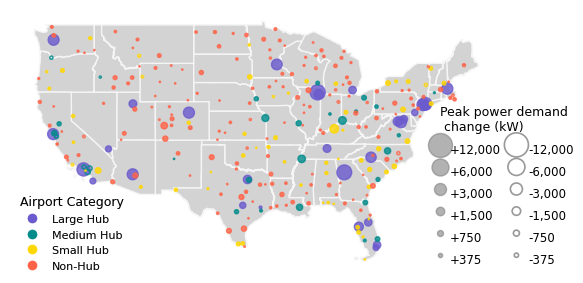

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# -------------------------------
# Plot setup
# -------------------------------
fig, ax = plt.subplots(figsize=(6, 4))

# Marker size normalization (magnitude only)
max_size = 12000
scale_factor = 300
normalize_size = lambda x: (abs(x) / max_size) * scale_factor

# Base map
us_mainland.plot(ax=ax, color='lightgrey', edgecolor='whitesmoke')

# -------------------------------
# Helper function for categories
# -------------------------------
def plot_category(df, color, label):
    # Positive values → filled circles
    pos = df[df['peak_demand_diff'] > 0]
    ax.scatter(
        pos.geometry.x,
        pos.geometry.y,
        s=normalize_size(pos['peak_demand_diff']),
        color=color,
        edgecolors=color,
        alpha=0.8,
        label=label
    )

    # Negative values → hollow circles
    neg = df[df['peak_demand_diff'] < 0]
    ax.scatter(
        neg.geometry.x,
        neg.geometry.y,
        s=normalize_size(neg['peak_demand_diff']),
        facecolors='none',
        edgecolors=color,
        linewidths=1.2,
        alpha=0.8
    )

# -------------------------------
# Plot airport categories
# -------------------------------
plot_category(peak_demand_df_S3_S1_diff_large,  'slateblue', 'Large Hub')
plot_category(peak_demand_df_S3_S1_diff_medium, 'darkcyan',  'Medium Hub')
plot_category(peak_demand_df_S3_S1_diff_small,  'gold',      'Small Hub')
plot_category(peak_demand_df_S3_S1_diff_nonhub, 'tomato',    'Non-Hub')

# -------------------------------
# Legend: Airport category (color)
# -------------------------------
color_legend = [
    Line2D([0], [0], marker='o', color='w', label='Large Hub',
           markerfacecolor='slateblue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Medium Hub',
           markerfacecolor='darkcyan', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Small Hub',
           markerfacecolor='gold', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Non-Hub',
           markerfacecolor='tomato', markersize=8)
]

legend1 = ax.legend(
    handles=color_legend,
    title='Airport Category',
    loc='lower left',
    bbox_to_anchor=(0, -0.03),
    fontsize=8,
    title_fontsize=9
)
ax.add_artist(legend1)
legend1.get_frame().set_linewidth(0)

# -------------------------------
# Legend: Sign (filled vs hollow)
# -------------------------------
sign_legend = [
    Line2D([0], [0], marker='o', color='black',
           label='Increase',
           markerfacecolor='black', markersize=8),
    Line2D([0], [0], marker='o', color='black',
           label='Decrease',
           markerfacecolor='none', markersize=8)
]

# -------------------------------
# Size legend (magnitude)
# -------------------------------
example_counts = [375, 750, 1500, 3000, 6000,12000]
x_pos, y_pos = -72, 25
dy = 2.3

for i, count in enumerate(example_counts):
    y = y_pos + i * dy

    # Positive (filled)
    ax.scatter(
        x_pos,
        y,
        s=normalize_size(count),
        color='gray',
        alpha=0.6
    )
    ax.text(x_pos + 1.3, y-0.5, f'+{count:,}', va='center', fontsize=8.5)

    # Negative (hollow)
    ax.scatter(
        x_pos + 10,
        y,
        s=normalize_size(count),
        facecolors='none',
        edgecolors='gray',
        linewidths=1.2,
        alpha=0.8
    )
    ax.text(x_pos + 11.5, y-0.5, f'-{count:,}', va='center', fontsize=8.5)

# Legend title
ax.text(x_pos, y_pos + len(example_counts)*2+1, 'Peak power demand\n change (kW)', fontsize=9)
# -------------------------------
# Final cleanup
# -------------------------------
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Figure4_c.pdf", format='pdf', bbox_inches='tight')
plt.show()


### Figure 4d

In [92]:
# Get peak demand for each airport in scenario 4
load_S4 = glob.glob(os.path.join(load_profiles_S4_path, '*.csv'))

airport_list = []
peak_demand_list = []

for file_path in load_S4:
    df_temp = pd.read_csv(file_path)
    airport = os.path.basename(file_path).split('_')[0]
    peak_demand = df_temp['power'].max()
    airport_list.append(airport)
    peak_demand_list.append(peak_demand)

peak_demand_df_S4 = pd.DataFrame({'airport':airport_list, 'peak_demand': peak_demand_list})

In [93]:
peak_demand_df_S4_location = pd.merge(peak_demand_df_S4, us_airports_gps[['iata_code', 'latitude_deg', 'longitude_deg', 'region_name']], left_on='airport', right_on='iata_code', how='inner')
peak_demand_df_S4_location['geometry'] = peak_demand_df_S4_location.apply(lambda row: Point(row['longitude_deg'], row['latitude_deg']), axis=1)
peak_demand_df_S4_location_gdf = gpd.GeoDataFrame(peak_demand_df_S4_location, geometry='geometry', crs='EPSG:4326')

In [94]:
# Peak demand difference between Scenario 4 and Scenario 1
peak_demand_df_S4_S1_diff_location_gdf = peak_demand_df_S4_location_gdf.merge(
    peak_demand_df_S1_location_gdf[['airport', 'peak_demand']],
    on='airport',
    suffixes=('_S4', '_S1')
)
peak_demand_df_S4_S1_diff_location_gdf['peak_demand_diff'] = peak_demand_df_S4_S1_diff_location_gdf['peak_demand_S4'] - peak_demand_df_S4_S1_diff_location_gdf['peak_demand_S1']

In [95]:
peak_demand_df_S4_large = peak_demand_df_S4_location_gdf[peak_demand_df_S4_location_gdf['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
peak_demand_df_S4_medium = peak_demand_df_S4_location_gdf[peak_demand_df_S4_location_gdf['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
peak_demand_df_S4_small= peak_demand_df_S4_location_gdf[peak_demand_df_S4_location_gdf['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
peak_demand_df_S4_nonhub = peak_demand_df_S4_location_gdf[peak_demand_df_S4_location_gdf['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]

In [96]:
peak_demand_df_S4_S1_diff_large = peak_demand_df_S4_S1_diff_location_gdf[peak_demand_df_S4_S1_diff_location_gdf['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
peak_demand_df_S4_S1_diff_medium = peak_demand_df_S4_S1_diff_location_gdf[peak_demand_df_S4_S1_diff_location_gdf['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
peak_demand_df_S4_S1_diff_small= peak_demand_df_S4_S1_diff_location_gdf[peak_demand_df_S4_S1_diff_location_gdf['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
peak_demand_df_S4_S1_diff_nonhub = peak_demand_df_S4_S1_diff_location_gdf[peak_demand_df_S4_S1_diff_location_gdf['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]

In [97]:
peak_demand_df_S4_S1_diff_large['peak_demand_diff'].max()

np.int64(2060)

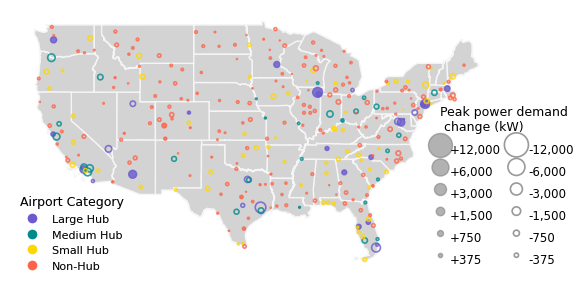

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------------------
# Plot setup
# -------------------------------
fig, ax = plt.subplots(figsize=(6, 4))

# Marker size normalization (magnitude only)
max_size = 12000
scale_factor = 300
normalize_size = lambda x: (abs(x) / max_size) * scale_factor

# Base map
us_mainland.plot(ax=ax, color='lightgrey', edgecolor='whitesmoke')

# -------------------------------
# Helper function for categories
# -------------------------------
def plot_category(df, color, label):
    # Positive values → filled circles
    pos = df[df['peak_demand_diff'] > 0]
    ax.scatter(
        pos.geometry.x,
        pos.geometry.y,
        s=normalize_size(pos['peak_demand_diff']),
        color=color,
        edgecolors=color,
        alpha=0.8,
        label=label
    )

    # Negative values → hollow circles
    neg = df[df['peak_demand_diff'] < 0]
    ax.scatter(
        neg.geometry.x,
        neg.geometry.y,
        s=normalize_size(neg['peak_demand_diff']),
        facecolors='none',
        edgecolors=color,
        linewidths=1.2,
        alpha=0.8
    )

# -------------------------------
# Plot airport categories
# -------------------------------
plot_category(peak_demand_df_S4_S1_diff_large,  'slateblue', 'Large Hub')
plot_category(peak_demand_df_S4_S1_diff_medium, 'darkcyan',  'Medium Hub')
plot_category(peak_demand_df_S4_S1_diff_small,  'gold',      'Small Hub')
plot_category(peak_demand_df_S4_S1_diff_nonhub, 'tomato',    'Non-Hub')

# -------------------------------
# Legend: Airport category (color)
# -------------------------------
color_legend = [
    Line2D([0], [0], marker='o', color='w', label='Large Hub',
           markerfacecolor='slateblue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Medium Hub',
           markerfacecolor='darkcyan', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Small Hub',
           markerfacecolor='gold', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Non-Hub',
           markerfacecolor='tomato', markersize=8)
]

legend1 = ax.legend(
    handles=color_legend,
    title='Airport Category',
    loc='lower left',
    bbox_to_anchor=(0, -0.03),
    fontsize=8,
    title_fontsize=9
)
ax.add_artist(legend1)
legend1.get_frame().set_linewidth(0)

# -------------------------------
# Legend: Sign (filled vs hollow)
# -------------------------------
sign_legend = [
    Line2D([0], [0], marker='o', color='black',
           label='Increase',
           markerfacecolor='black', markersize=8),
    Line2D([0], [0], marker='o', color='black',
           label='Decrease',
           markerfacecolor='none', markersize=8)
]

# -------------------------------
# Size legend (magnitude)
# -------------------------------
example_counts = [375, 750, 1500, 3000, 6000,12000]
x_pos, y_pos = -72, 25
dy = 2.3

for i, count in enumerate(example_counts):
    y = y_pos + i * dy

    # Positive (filled)
    ax.scatter(
        x_pos,
        y,
        s=normalize_size(count),
        color='gray',
        alpha=0.6
    )
    ax.text(x_pos + 1.3, y-0.5, f'+{count:,}', va='center', fontsize=8.5)

    # Negative (hollow)
    ax.scatter(
        x_pos + 10,
        y,
        s=normalize_size(count),
        facecolors='none',
        edgecolors='gray',
        linewidths=1.2,
        alpha=0.8
    )
    ax.text(x_pos + 11.5, y-0.5, f'-{count:,}', va='center', fontsize=8.5)

# Legend title
ax.text(x_pos, y_pos + len(example_counts)*2+1, 'Peak power demand\n change (kW)', fontsize=9)
# -------------------------------
# Final cleanup
# -------------------------------
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Figure4_d.pdf", format='pdf', bbox_inches='tight')
plt.show()


### Figure 4e

In [100]:
# Get peak demand for each airport in scenario 5
load_S5 = glob.glob(os.path.join(load_profiles_S5_path, '*.csv'))

airport_list = []
peak_demand_list = []

for file_path in load_S5:
    df_temp = pd.read_csv(file_path)
    airport = os.path.basename(file_path).split('_')[0]
    peak_demand = df_temp['power'].max()
    airport_list.append(airport)
    peak_demand_list.append(peak_demand)

peak_demand_df_S5 = pd.DataFrame({'airport':airport_list, 'peak_demand': peak_demand_list})

In [101]:
peak_demand_df_S5_location = pd.merge(peak_demand_df_S5, us_airports_gps[['iata_code', 'latitude_deg', 'longitude_deg', 'region_name']], left_on='airport', right_on='iata_code', how='inner')
peak_demand_df_S5_location['geometry'] = peak_demand_df_S5_location.apply(lambda row: Point(row['longitude_deg'], row['latitude_deg']), axis=1)
peak_demand_df_S5_location_gdf = gpd.GeoDataFrame(peak_demand_df_S5_location, geometry='geometry', crs='EPSG:4326')

In [102]:
# Difference in peak demand between Scenario 5 and Scenario 1
peak_demand_df_S5_S1_diff_location_gdf = peak_demand_df_S5_location_gdf.merge(
    peak_demand_df_S1_location_gdf[['airport', 'peak_demand']],
    on='airport',
    suffixes=('_S5', '_S1')
)
peak_demand_df_S5_S1_diff_location_gdf['peak_demand_diff'] = peak_demand_df_S5_S1_diff_location_gdf['peak_demand_S5'] - peak_demand_df_S5_S1_diff_location_gdf['peak_demand_S1']   

In [103]:
peak_demand_df_S5_location_gdf['peak_demand'].max()

np.int64(25480)

In [104]:
peak_demand_df_S5_large = peak_demand_df_S5_location_gdf[peak_demand_df_S5_location_gdf['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
peak_demand_df_S5_medium = peak_demand_df_S5_location_gdf[peak_demand_df_S5_location_gdf['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
peak_demand_df_S5_small= peak_demand_df_S5_location_gdf[peak_demand_df_S5_location_gdf['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
peak_demand_df_S5_nonhub = peak_demand_df_S5_location_gdf[peak_demand_df_S5_location_gdf['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]

In [105]:
peak_demand_df_S5_S1_diff_large = peak_demand_df_S5_S1_diff_location_gdf[peak_demand_df_S5_S1_diff_location_gdf['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
peak_demand_df_S5_S1_diff_medium = peak_demand_df_S5_S1_diff_location_gdf[peak_demand_df_S5_S1_diff_location_gdf['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
peak_demand_df_S5_S1_diff_small= peak_demand_df_S5_S1_diff_location_gdf[peak_demand_df_S5_S1_diff_location_gdf['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
peak_demand_df_S5_S1_diff_nonhub = peak_demand_df_S5_S1_diff_location_gdf[peak_demand_df_S5_S1_diff_location_gdf['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]

In [106]:
peak_demand_df_S5_S1_diff_large['peak_demand_diff'].max()

np.int64(11840)

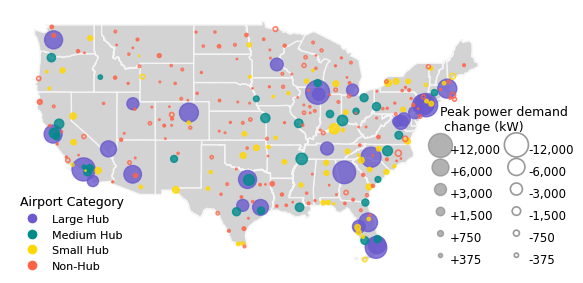

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------------------
# Plot setup
# -------------------------------
fig, ax = plt.subplots(figsize=(6, 4))

# Marker size normalization (magnitude only)
max_size = 12000
scale_factor = 300
normalize_size = lambda x: (abs(x) / max_size) * scale_factor

# Base map
us_mainland.plot(ax=ax, color='lightgrey', edgecolor='whitesmoke')

# -------------------------------
# Helper function for categories
# -------------------------------
def plot_category(df, color, label):
    # Positive values → filled circles
    pos = df[df['peak_demand_diff'] > 0]
    ax.scatter(
        pos.geometry.x,
        pos.geometry.y,
        s=normalize_size(pos['peak_demand_diff']),
        color=color,
        edgecolors=color,
        alpha=0.8,
        label=label
    )

    # Negative values → hollow circles
    neg = df[df['peak_demand_diff'] < 0]
    ax.scatter(
        neg.geometry.x,
        neg.geometry.y,
        s=normalize_size(neg['peak_demand_diff']),
        facecolors='none',
        edgecolors=color,
        linewidths=1.2,
        alpha=0.8
    )

# -------------------------------
# Plot airport categories
# -------------------------------
plot_category(peak_demand_df_S5_S1_diff_large,  'slateblue', 'Large Hub')
plot_category(peak_demand_df_S5_S1_diff_medium, 'darkcyan',  'Medium Hub')
plot_category(peak_demand_df_S5_S1_diff_small,  'gold',      'Small Hub')
plot_category(peak_demand_df_S5_S1_diff_nonhub, 'tomato',    'Non-Hub')

# -------------------------------
# Legend: Airport category (color)
# -------------------------------
color_legend = [
    Line2D([0], [0], marker='o', color='w', label='Large Hub',
           markerfacecolor='slateblue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Medium Hub',
           markerfacecolor='darkcyan', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Small Hub',
           markerfacecolor='gold', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Non-Hub',
           markerfacecolor='tomato', markersize=8)
]

legend1 = ax.legend(
    handles=color_legend,
    title='Airport Category',
    loc='lower left',
    bbox_to_anchor=(0, -0.03),
    fontsize=8,
    title_fontsize=9
)
ax.add_artist(legend1)
legend1.get_frame().set_linewidth(0)

# -------------------------------
# Legend: Sign (filled vs hollow)
# -------------------------------
sign_legend = [
    Line2D([0], [0], marker='o', color='black',
           label='Increase',
           markerfacecolor='black', markersize=8),
    Line2D([0], [0], marker='o', color='black',
           label='Decrease',
           markerfacecolor='none', markersize=8)
]

# -------------------------------
# Size legend (magnitude)
# -------------------------------
example_counts = [375, 750, 1500, 3000, 6000,12000]
x_pos, y_pos = -72, 25
dy = 2.3

for i, count in enumerate(example_counts):
    y = y_pos + i * dy

    # Positive (filled)
    ax.scatter(
        x_pos,
        y,
        s=normalize_size(count),
        color='gray',
        alpha=0.6
    )
    ax.text(x_pos + 1.3, y-0.5, f'+{count:,}', va='center', fontsize=8.5)

    # Negative (hollow)
    ax.scatter(
        x_pos + 10,
        y,
        s=normalize_size(count),
        facecolors='none',
        edgecolors='gray',
        linewidths=1.2,
        alpha=0.8
    )
    ax.text(x_pos + 11.5, y-0.5, f'-{count:,}', va='center', fontsize=8.5)

# Legend title
ax.text(x_pos, y_pos + len(example_counts)*2+1, 'Peak power demand\n change (kW)', fontsize=9)
# -------------------------------
# Final cleanup
# -------------------------------
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Figure4_e.pdf", format='pdf', bbox_inches='tight')
plt.show()


### Figure 4f

In [109]:
# Get peak demand for each airport in scenario 6
load_S6 = glob.glob(os.path.join(load_profiles_S6_path, '*.csv'))

airport_list = []
peak_demand_list = []

for file_path in load_S6:
    df_temp = pd.read_csv(file_path)
    airport = os.path.basename(file_path).split('_')[0]
    peak_demand = df_temp['power'].max()
    airport_list.append(airport)
    peak_demand_list.append(peak_demand)

peak_demand_df_S6 = pd.DataFrame({'airport':airport_list, 'peak_demand': peak_demand_list})

In [110]:
peak_demand_df_S6_location = pd.merge(peak_demand_df_S6, us_airports_gps[['iata_code', 'latitude_deg', 'longitude_deg', 'region_name']], left_on='airport', right_on='iata_code', how='inner')
peak_demand_df_S6_location['geometry'] = peak_demand_df_S6_location.apply(lambda row: Point(row['longitude_deg'], row['latitude_deg']), axis=1)
peak_demand_df_S6_location_gdf = gpd.GeoDataFrame(peak_demand_df_S6_location, geometry='geometry', crs='EPSG:4326')

In [111]:
# Difference in peak demand between Scenario 6 and Scenario 1
peak_demand_df_S6_S1_diff_location_gdf = peak_demand_df_S6_location_gdf.merge(
    peak_demand_df_S1_location_gdf[['airport', 'peak_demand']],
    on='airport',
    suffixes=('_S6', '_S1')
)
peak_demand_df_S6_S1_diff_location_gdf['peak_demand_diff'] = peak_demand_df_S6_S1_diff_location_gdf['peak_demand_S6'] - peak_demand_df_S6_S1_diff_location_gdf['peak_demand_S1']

In [112]:
peak_demand_df_S6_location_gdf['peak_demand'].max()

np.int64(20220)

In [113]:
peak_demand_df_S6_large = peak_demand_df_S6_location_gdf[peak_demand_df_S6_location_gdf['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
peak_demand_df_S6_medium = peak_demand_df_S6_location_gdf[peak_demand_df_S6_location_gdf['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
peak_demand_df_S6_small= peak_demand_df_S6_location_gdf[peak_demand_df_S6_location_gdf['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
peak_demand_df_S6_nonhub = peak_demand_df_S6_location_gdf[peak_demand_df_S6_location_gdf['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]

In [114]:
peak_demand_df_S6_S1_diff_large = peak_demand_df_S6_S1_diff_location_gdf[peak_demand_df_S6_S1_diff_location_gdf['airport'].isin(annual_flight_count_mainland_large['airport'].to_list())]
peak_demand_df_S6_S1_diff_medium = peak_demand_df_S6_S1_diff_location_gdf[peak_demand_df_S6_S1_diff_location_gdf['airport'].isin(annual_flight_count_mainland_medium['airport'].to_list())]
peak_demand_df_S6_S1_diff_small= peak_demand_df_S6_S1_diff_location_gdf[peak_demand_df_S6_S1_diff_location_gdf['airport'].isin(annual_flight_count_mainland_small['airport'].to_list())]
peak_demand_df_S6_S1_diff_nonhub = peak_demand_df_S6_S1_diff_location_gdf[peak_demand_df_S6_S1_diff_location_gdf['airport'].isin(annual_flight_count_mainland_non_hub['airport'].to_list())]    

In [115]:
peak_demand_df_S6_S1_diff_large['peak_demand_diff'].max()

np.int64(7440)

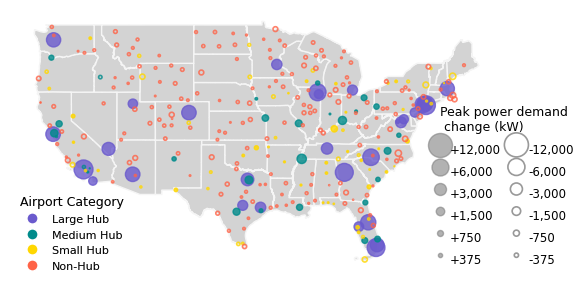

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------------------
# Plot setup
# -------------------------------
fig, ax = plt.subplots(figsize=(6, 4))

# Marker size normalization (magnitude only)
max_size = 12000
scale_factor = 300
normalize_size = lambda x: (abs(x) / max_size) * scale_factor

# Base map
us_mainland.plot(ax=ax, color='lightgrey', edgecolor='whitesmoke')

# -------------------------------
# Helper function for categories
# -------------------------------
def plot_category(df, color, label):
    # Positive values → filled circles
    pos = df[df['peak_demand_diff'] > 0]
    ax.scatter(
        pos.geometry.x,
        pos.geometry.y,
        s=normalize_size(pos['peak_demand_diff']),
        color=color,
        edgecolors=color,
        alpha=0.8,
        label=label
    )

    # Negative values → hollow circles
    neg = df[df['peak_demand_diff'] < 0]
    ax.scatter(
        neg.geometry.x,
        neg.geometry.y,
        s=normalize_size(neg['peak_demand_diff']),
        facecolors='none',
        edgecolors=color,
        linewidths=1.2,
        alpha=0.8
    )

# -------------------------------
# Plot airport categories
# -------------------------------
plot_category(peak_demand_df_S6_S1_diff_large,  'slateblue', 'Large Hub')
plot_category(peak_demand_df_S6_S1_diff_medium, 'darkcyan',  'Medium Hub')
plot_category(peak_demand_df_S6_S1_diff_small,  'gold',      'Small Hub')
plot_category(peak_demand_df_S6_S1_diff_nonhub, 'tomato',    'Non-Hub')

# -------------------------------
# Legend: Airport category (color)
# -------------------------------
color_legend = [
    Line2D([0], [0], marker='o', color='w', label='Large Hub',
           markerfacecolor='slateblue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Medium Hub',
           markerfacecolor='darkcyan', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Small Hub',
           markerfacecolor='gold', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Non-Hub',
           markerfacecolor='tomato', markersize=8)
]

legend1 = ax.legend(
    handles=color_legend,
    title='Airport Category',
    loc='lower left',
    bbox_to_anchor=(0, -0.03),
    fontsize=8,
    title_fontsize=9
)
ax.add_artist(legend1)
legend1.get_frame().set_linewidth(0)

# -------------------------------
# Legend: Sign (filled vs hollow)
# -------------------------------
sign_legend = [
    Line2D([0], [0], marker='o', color='black',
           label='Increase',
           markerfacecolor='black', markersize=8),
    Line2D([0], [0], marker='o', color='black',
           label='Decrease',
           markerfacecolor='none', markersize=8)
]

# -------------------------------
# Size legend (magnitude)
# -------------------------------
example_counts = [375, 750, 1500, 3000, 6000,12000]
x_pos, y_pos = -72, 25
dy = 2.3

for i, count in enumerate(example_counts):
    y = y_pos + i * dy

    # Positive (filled)
    ax.scatter(
        x_pos,
        y,
        s=normalize_size(count),
        color='gray',
        alpha=0.6
    )
    ax.text(x_pos + 1.3, y-0.5, f'+{count:,}', va='center', fontsize=8.5)

    # Negative (hollow)
    ax.scatter(
        x_pos + 10,
        y,
        s=normalize_size(count),
        facecolors='none',
        edgecolors='gray',
        linewidths=1.2,
        alpha=0.8
    )
    ax.text(x_pos + 11.5, y-0.5, f'-{count:,}', va='center', fontsize=8.5)

# Legend title
ax.text(x_pos, y_pos + len(example_counts)*2+1, 'Peak power demand\n change (kW)', fontsize=9)
# -------------------------------
# Final cleanup
# -------------------------------
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Figure4_f.pdf", format='pdf', bbox_inches='tight')
plt.show()


### Figure 3a

In [155]:
load_S1 = glob.glob(os.path.join(load_profiles_S1_path, '*.csv'))

dic_load_all_airports_S1 = {}

for file_path in load_S1:
    df_temp = pd.read_csv(file_path)
    airport = os.path.basename(file_path).split('_')[0]

    temp_load_profile = df_temp[df_temp['time_stamp'].str.contains(('2023-10-20'))]
    temp_load_profile['time_stamp'] = pd.to_datetime(temp_load_profile['time_stamp'], format="%Y-%m-%d %H:%M:%S")
    temp_load_profile = temp_load_profile.sort_values(by='time_stamp')
    power_list = temp_load_profile.power.to_list()
    dic_load_all_airports_S1[airport] = power_list

/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/2612785768.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_load_profile['time_stamp'] = pd.to_datetime(temp_load_profile['time_stamp'], format="%Y-%m-%d %H:%M:%S")
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/2612785768.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_load_profile['time_stamp'] = pd.to_datetime(temp_load_profile['time_stamp'], format="%Y-%m-%d %H:%M:%S")
/var/folders/31/y4mwl1qs14z8r1x7g524

In [156]:
df_load_all_airports_S1 = pd.DataFrame(dic_load_all_airports_S1)

df_load_all_airports_S1_large = df_load_all_airports_S1[annual_flight_count_mainland_large['airport'].to_list()]

df_load_all_airports_S1_medium = df_load_all_airports_S1[annual_flight_count_mainland_medium['airport'].to_list()]

df_load_all_airports_S1_small = df_load_all_airports_S1[annual_flight_count_mainland_small['airport'].to_list()]

df_load_all_airports_S1_nonhub = df_load_all_airports_S1[annual_flight_count_mainland_non_hub['airport'].to_list()]


In [157]:
df_load_all_airports_S1_large.shape

(1440, 30)

In [158]:
# choose 5 airports from each category to represent daily flight arrival counts
large_5_airports = ['ATL', 'DEN', 'DFW', 'ORD', 'LAX']
medium_5_airports = ['MEM', 'PDX', 'DAL', 'CVG', 'STL']
small_5_airports = ['SDF', 'GEG', 'OKC', 'ORF', 'BUF']
nonhub_5_airports = ['BIL', 'RFD', 'TLH', 'FWA', 'ROA']

In [159]:
df_load_all_airports_S1_large_10 = df_load_all_airports_S1_large[large_5_airports]
df_load_all_airports_S1_medium_10 = df_load_all_airports_S1_medium[medium_5_airports]
df_load_all_airports_S1_small_10 = df_load_all_airports_S1_small[small_5_airports]
df_load_all_airports_S1_nonhub_10 = df_load_all_airports_S1_nonhub[nonhub_5_airports]

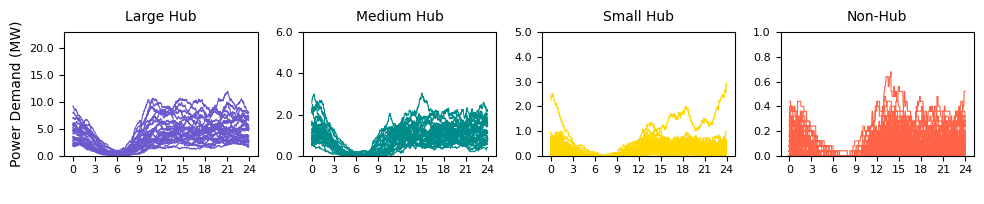

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MaxNLocator, FormatStrFormatter


fig, axes = plt.subplots(1, 4, figsize=(10, 2.2), sharey=False)  # sharey=True means all share same y-axis scale
axes = axes.flatten()

df_1 = df_load_all_airports_S1_large.copy()
df_1.index = df_1.index / 60
df_1 = df_1 / 1000

df_2 = df_load_all_airports_S1_medium.copy()
df_2.index = df_2.index / 60
df_2 = df_2 / 1000

df_3 = df_load_all_airports_S1_small.copy()
df_3.index = df_3.index / 60
df_3 = df_3 / 1000

df_4 = df_load_all_airports_S1_nonhub.copy()
df_4.index = df_4.index / 60
df_4 = df_4 / 1000

df_1.iloc[:, :-3].plot(ax=axes[0], color='slateblue', legend=False, linewidth=0.8)
df_2.iloc[:, :-3].plot(ax=axes[1], color='darkcyan', legend=False, linewidth=0.8)
df_3.iloc[:, :-3].plot(ax=axes[2], color='gold', legend=False, linewidth=0.8)
df_4.iloc[:, :-3].plot(ax=axes[3], color='tomato', legend=False, linewidth=0.8)

for ax in axes:
    ax.grid(False)
    ax.tick_params(axis='y', left=True, labelleft=True, labelsize = 8)
    ax.tick_params(axis='x', labelsize = 8)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=10, integer=True))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    ax.set_xlabel(' ')

axes[0].set_ylabel('Power Demand (MW)', fontsize=10)


# Set individual y limits (replace with your actual min and max for each)
axes[0].set_ylim(0, 23)
axes[1].set_ylim(0, 6)
axes[2].set_ylim(0, 5)
axes[3].set_ylim(0, 1)

axes[0].set_title("Large Hub", fontsize=10, pad=8)
axes[1].set_title("Medium Hub", fontsize=10, pad=8)
axes[2].set_title("Small Hub", fontsize=10, pad=8)
axes[3].set_title("Non-Hub", fontsize=10, pad=8)

plt.tight_layout()
plt.savefig("Figure3_a.pdf", format='pdf', bbox_inches='tight')
plt.show()

### Figure 3b

In [162]:
load_S2 = glob.glob(os.path.join(load_profiles_S2_path, '*.csv'))

dic_load_all_airports_S2 = {}

for file_path in load_S2:
    df_temp = pd.read_csv(file_path)
    airport = os.path.basename(file_path).split('_')[0]

    temp_load_profile = df_temp[df_temp['time_stamp'].str.contains(('2023-10-20'))]
    temp_load_profile['time_stamp'] = pd.to_datetime(temp_load_profile['time_stamp'], format="%Y-%m-%d %H:%M:%S")
    temp_load_profile = temp_load_profile.sort_values(by='time_stamp')
    power_list = temp_load_profile.power.to_list()
    dic_load_all_airports_S2[airport] = power_list

/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/76161604.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_load_profile['time_stamp'] = pd.to_datetime(temp_load_profile['time_stamp'], format="%Y-%m-%d %H:%M:%S")
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/76161604.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_load_profile['time_stamp'] = pd.to_datetime(temp_load_profile['time_stamp'], format="%Y-%m-%d %H:%M:%S")
/var/folders/31/y4mwl1qs14z8r1x7g524813c

In [163]:
df_load_all_airports_S2 = pd.DataFrame(dic_load_all_airports_S2)

df_load_all_airports_S2_large = df_load_all_airports_S2[annual_flight_count_mainland_large['airport'].to_list()]

df_load_all_airports_S2_medium = df_load_all_airports_S2[annual_flight_count_mainland_medium['airport'].to_list()]

df_load_all_airports_S2_small = df_load_all_airports_S2[annual_flight_count_mainland_small['airport'].to_list()]

df_load_all_airports_S2_nonhub = df_load_all_airports_S2[annual_flight_count_mainland_non_hub['airport'].to_list()]


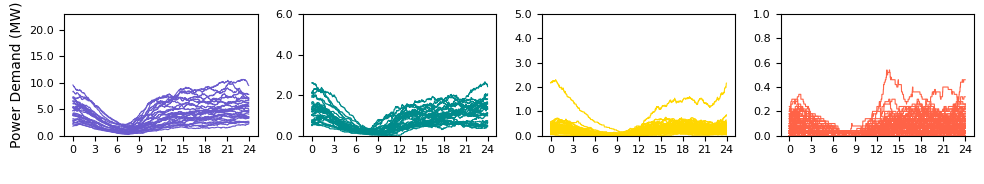

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MaxNLocator, FormatStrFormatter


fig, axes = plt.subplots(1, 4, figsize=(10, 2), sharey=False)  # sharey=True means all share same y-axis scale
axes = axes.flatten()

df_1 = df_load_all_airports_S2_large.copy()
df_1.index = df_1.index / 60
df_1 = df_1 / 1000

df_2 = df_load_all_airports_S2_medium.copy()
df_2.index = df_2.index / 60
df_2 = df_2 / 1000

df_3 = df_load_all_airports_S2_small.copy()
df_3.index = df_3.index / 60
df_3 = df_3 / 1000

df_4 = df_load_all_airports_S2_nonhub.copy()
df_4.index = df_4.index / 60
df_4 = df_4 / 1000

df_1.iloc[:, :-3].plot(ax=axes[0], color='slateblue', legend=False, linewidth=0.8)
df_2.iloc[:, :-3].plot(ax=axes[1], color='darkcyan', legend=False, linewidth=0.8)
df_3.iloc[:, :-3].plot(ax=axes[2], color='gold', legend=False, linewidth=0.8)
df_4.iloc[:, :-3].plot(ax=axes[3], color='tomato', legend=False, linewidth=0.8)

for ax in axes:
    ax.grid(False)
    ax.tick_params(axis='y', left=True, labelleft=True, labelsize = 8)
    ax.tick_params(axis='x', labelsize = 8)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=10, integer=True))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    ax.set_xlabel(' ')

axes[0].set_ylabel('Power Demand (MW)', fontsize=10)

# Set individual y limits (replace with your actual min and max for each)
axes[0].set_ylim(0, 23)
axes[1].set_ylim(0, 6)
axes[2].set_ylim(0, 5)
axes[3].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("Figure3_b.pdf", format='pdf', bbox_inches='tight')
plt.show()

### Figure 3c

In [165]:
load_S3 = glob.glob(os.path.join(load_profiles_S3_path, '*.csv'))

dic_load_all_airports_S3 = {}

for file_path in load_S3:
    df_temp = pd.read_csv(file_path)
    airport = os.path.basename(file_path).split('_')[0]

    temp_load_profile = df_temp[df_temp['time_stamp'].str.contains(('2023-10-20'))]
    temp_load_profile['time_stamp'] = pd.to_datetime(temp_load_profile['time_stamp'], format="%Y-%m-%d %H:%M:%S")
    temp_load_profile = temp_load_profile.sort_values(by='time_stamp')
    power_list = temp_load_profile.power.to_list()
    dic_load_all_airports_S3[airport] = power_list

/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/691274989.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_load_profile['time_stamp'] = pd.to_datetime(temp_load_profile['time_stamp'], format="%Y-%m-%d %H:%M:%S")
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/691274989.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_load_profile['time_stamp'] = pd.to_datetime(temp_load_profile['time_stamp'], format="%Y-%m-%d %H:%M:%S")
/var/folders/31/y4mwl1qs14z8r1x7g52481

In [166]:
df_load_all_airports_S3 = pd.DataFrame(dic_load_all_airports_S3)

df_load_all_airports_S3_large = df_load_all_airports_S3[annual_flight_count_mainland_large['airport'].to_list()]

df_load_all_airports_S3_medium = df_load_all_airports_S3[annual_flight_count_mainland_medium['airport'].to_list()]

df_load_all_airports_S3_small = df_load_all_airports_S3[annual_flight_count_mainland_small['airport'].to_list()]

df_load_all_airports_S3_nonhub = df_load_all_airports_S3[annual_flight_count_mainland_non_hub['airport'].to_list()]


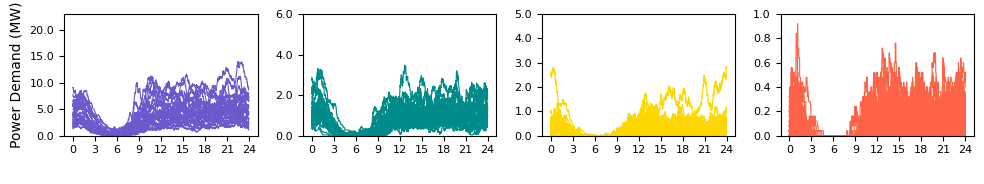

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MaxNLocator, FormatStrFormatter


fig, axes = plt.subplots(1, 4, figsize=(10, 2), sharey=False)  # sharey=True means all share same y-axis scale
axes = axes.flatten()

df_1 = df_load_all_airports_S3_large.copy()
df_1.index = df_1.index / 60
df_1 = df_1 / 1000

df_2 = df_load_all_airports_S3_medium.copy()
df_2.index = df_2.index / 60
df_2 = df_2 / 1000

df_3 = df_load_all_airports_S3_small.copy()
df_3.index = df_3.index / 60
df_3 = df_3 / 1000

df_4 = df_load_all_airports_S3_nonhub.copy()
df_4.index = df_4.index / 60
df_4 = df_4 / 1000

df_1.iloc[:, :-3].plot(ax=axes[0], color='slateblue', legend=False, linewidth=0.8)
df_2.iloc[:, :-3].plot(ax=axes[1], color='darkcyan', legend=False, linewidth=0.8)
df_3.iloc[:, :-3].plot(ax=axes[2], color='gold', legend=False, linewidth=0.8)
df_4.iloc[:, :-3].plot(ax=axes[3], color='tomato', legend=False, linewidth=0.8)

for ax in axes:
    ax.grid(False)
    ax.tick_params(axis='y', left=True, labelleft=True, labelsize = 8)
    ax.tick_params(axis='x', labelsize = 8)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=10, integer=True))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    ax.set_xlabel(' ')

axes[0].set_ylabel('Power Demand (MW)', fontsize=10)

# Set individual y limits (replace with your actual min and max for each)
axes[0].set_ylim(0, 23)
axes[1].set_ylim(0, 6)
axes[2].set_ylim(0, 5)
axes[3].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("Figure3_c.pdf", format='pdf', bbox_inches='tight')
plt.show()

### Figure 3d

In [168]:
load_S4 = glob.glob(os.path.join(load_profiles_S4_path, '*.csv'))

dic_load_all_airports_S4 = {}

for file_path in load_S4:
    df_temp = pd.read_csv(file_path)
    airport = os.path.basename(file_path).split('_')[0]

    temp_load_profile = df_temp[df_temp['time_stamp'].str.contains(('2023-10-20'))]
    temp_load_profile['time_stamp'] = pd.to_datetime(temp_load_profile['time_stamp'], format="%Y-%m-%d %H:%M:%S")
    temp_load_profile = temp_load_profile.sort_values(by='time_stamp')
    power_list = temp_load_profile.power.to_list()
    dic_load_all_airports_S4[airport] = power_list

/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/539401918.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_load_profile['time_stamp'] = pd.to_datetime(temp_load_profile['time_stamp'], format="%Y-%m-%d %H:%M:%S")
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/539401918.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_load_profile['time_stamp'] = pd.to_datetime(temp_load_profile['time_stamp'], format="%Y-%m-%d %H:%M:%S")
/var/folders/31/y4mwl1qs14z8r1x7g52481

In [169]:
df_load_all_airports_S4 = pd.DataFrame(dic_load_all_airports_S4)

df_load_all_airports_S4_large = df_load_all_airports_S4[annual_flight_count_mainland_large['airport'].to_list()]

df_load_all_airports_S4_medium = df_load_all_airports_S4[annual_flight_count_mainland_medium['airport'].to_list()]

df_load_all_airports_S4_small = df_load_all_airports_S4[annual_flight_count_mainland_small['airport'].to_list()]

df_load_all_airports_S4_nonhub = df_load_all_airports_S4[annual_flight_count_mainland_non_hub['airport'].to_list()]


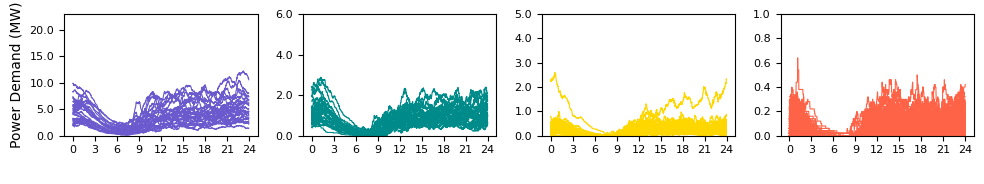

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MaxNLocator, FormatStrFormatter


fig, axes = plt.subplots(1, 4, figsize=(10, 2), sharey=False)  # sharey=True means all share same y-axis scale
axes = axes.flatten()

df_1 = df_load_all_airports_S4_large.copy()
df_1.index = df_1.index / 60
df_1 = df_1 / 1000

df_2 = df_load_all_airports_S4_medium.copy()
df_2.index = df_2.index / 60
df_2 = df_2 / 1000

df_3 = df_load_all_airports_S4_small.copy()
df_3.index = df_3.index / 60
df_3 = df_3 / 1000

df_4 = df_load_all_airports_S4_nonhub.copy()
df_4.index = df_4.index / 60
df_4 = df_4 / 1000

df_1.iloc[:, :-3].plot(ax=axes[0], color='slateblue', legend=False, linewidth=0.8)
df_2.iloc[:, :-3].plot(ax=axes[1], color='darkcyan', legend=False, linewidth=0.8)
df_3.iloc[:, :-3].plot(ax=axes[2], color='gold', legend=False, linewidth=0.8)
df_4.iloc[:, :-3].plot(ax=axes[3], color='tomato', legend=False, linewidth=0.8)

for ax in axes:
    ax.grid(False)
    ax.tick_params(axis='y', left=True, labelleft=True, labelsize = 8)
    ax.tick_params(axis='x', labelsize = 8)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=10, integer=True))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    ax.set_xlabel(' ')

axes[0].set_ylabel('Power Demand (MW)', fontsize=10)

# Set individual y limits (replace with your actual min and max for each)
axes[0].set_ylim(0, 23)
axes[1].set_ylim(0, 6)
axes[2].set_ylim(0, 5)
axes[3].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("Figure3_d.pdf", format='pdf', bbox_inches='tight')
plt.show()

### Figure 3e

In [171]:
load_S5 = glob.glob(os.path.join(load_profiles_S5_path, '*.csv'))

dic_load_all_airports_S5 = {}

for file_path in load_S5:
    df_temp = pd.read_csv(file_path)
    airport = os.path.basename(file_path).split('_')[0]

    temp_load_profile = df_temp[df_temp['time_stamp'].str.contains(('2023-10-20'))]
    temp_load_profile['time_stamp'] = pd.to_datetime(temp_load_profile['time_stamp'], format="%Y-%m-%d %H:%M:%S")
    temp_load_profile = temp_load_profile.sort_values(by='time_stamp')
    power_list = temp_load_profile.power.to_list()
    dic_load_all_airports_S5[airport] = power_list

/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/850054236.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_load_profile['time_stamp'] = pd.to_datetime(temp_load_profile['time_stamp'], format="%Y-%m-%d %H:%M:%S")
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/850054236.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_load_profile['time_stamp'] = pd.to_datetime(temp_load_profile['time_stamp'], format="%Y-%m-%d %H:%M:%S")
/var/folders/31/y4mwl1qs14z8r1x7g52481

In [172]:
df_load_all_airports_S5 = pd.DataFrame(dic_load_all_airports_S5)

df_load_all_airports_S5_large = df_load_all_airports_S5[annual_flight_count_mainland_large['airport'].to_list()]

df_load_all_airports_S5_medium = df_load_all_airports_S5[annual_flight_count_mainland_medium['airport'].to_list()]

df_load_all_airports_S5_small = df_load_all_airports_S5[annual_flight_count_mainland_small['airport'].to_list()]

df_load_all_airports_S5_nonhub = df_load_all_airports_S5[annual_flight_count_mainland_non_hub['airport'].to_list()]


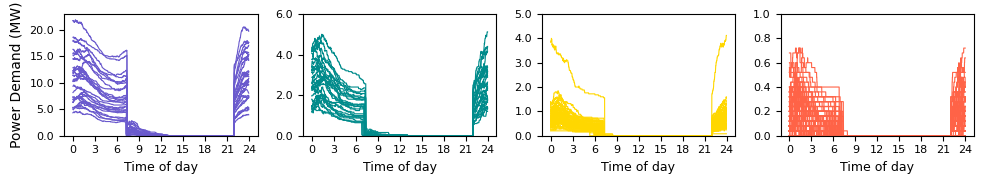

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MaxNLocator, FormatStrFormatter


fig, axes = plt.subplots(1, 4, figsize=(10, 2), sharey=False)  # sharey=True means all share same y-axis scale
axes = axes.flatten()

df_1 = df_load_all_airports_S5_large.copy()
df_1.index = df_1.index / 60
df_1 = df_1 / 1000

df_2 = df_load_all_airports_S5_medium.copy()
df_2.index = df_2.index / 60
df_2 = df_2 / 1000

df_3 = df_load_all_airports_S5_small.copy()
df_3.index = df_3.index / 60
df_3 = df_3 / 1000

df_4 = df_load_all_airports_S5_nonhub.copy()
df_4.index = df_4.index / 60
df_4 = df_4 / 1000

df_1.iloc[:, :-3].plot(ax=axes[0], color='slateblue', legend=False, linewidth=0.8)
df_2.iloc[:, :-3].plot(ax=axes[1], color='darkcyan', legend=False, linewidth=0.8)
df_3.iloc[:, :-3].plot(ax=axes[2], color='gold', legend=False, linewidth=0.8)
df_4.iloc[:, :-3].plot(ax=axes[3], color='tomato', legend=False, linewidth=0.8)

for ax in axes:
    ax.grid(False)
    ax.tick_params(axis='y', left=True, labelleft=True, labelsize = 8)
    ax.tick_params(axis='x', labelsize = 8)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=10, integer=True))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    ax.set_xlabel('Time of day')

axes[0].set_ylabel('Power Demand (MW)', fontsize=10)

# Set individual y limits (replace with your actual min and max for each)
axes[0].set_ylim(0, 23)
axes[1].set_ylim(0, 6)
axes[2].set_ylim(0, 5)
axes[3].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("Figure3_e.pdf", format='pdf', bbox_inches='tight')
plt.show()

### Figure 3f

In [174]:
load_S6 = glob.glob(os.path.join(load_profiles_S6_path, '*.csv'))

dic_load_all_airports_S6 = {}

for file_path in load_S6:
    df_temp = pd.read_csv(file_path)
    airport = os.path.basename(file_path).split('_')[0]

    temp_load_profile = df_temp[df_temp['time_stamp'].str.contains(('2023-10-20'))]
    temp_load_profile['time_stamp'] = pd.to_datetime(temp_load_profile['time_stamp'], format="%Y-%m-%d %H:%M:%S")
    temp_load_profile = temp_load_profile.sort_values(by='time_stamp')
    power_list = temp_load_profile.power.to_list()
    dic_load_all_airports_S6[airport] = power_list

/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/2306736636.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_load_profile['time_stamp'] = pd.to_datetime(temp_load_profile['time_stamp'], format="%Y-%m-%d %H:%M:%S")
/var/folders/31/y4mwl1qs14z8r1x7g524813cc7rklk/T/ipykernel_7881/2306736636.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_load_profile['time_stamp'] = pd.to_datetime(temp_load_profile['time_stamp'], format="%Y-%m-%d %H:%M:%S")
/var/folders/31/y4mwl1qs14z8r1x7g524

In [175]:
df_load_all_airports_S6 = pd.DataFrame(dic_load_all_airports_S6)

df_load_all_airports_S6_large = df_load_all_airports_S6[annual_flight_count_mainland_large['airport'].to_list()]

df_load_all_airports_S6_medium = df_load_all_airports_S6[annual_flight_count_mainland_medium['airport'].to_list()]

df_load_all_airports_S6_small = df_load_all_airports_S6[annual_flight_count_mainland_small['airport'].to_list()]

df_load_all_airports_S6_nonhub = df_load_all_airports_S6[annual_flight_count_mainland_non_hub['airport'].to_list()]


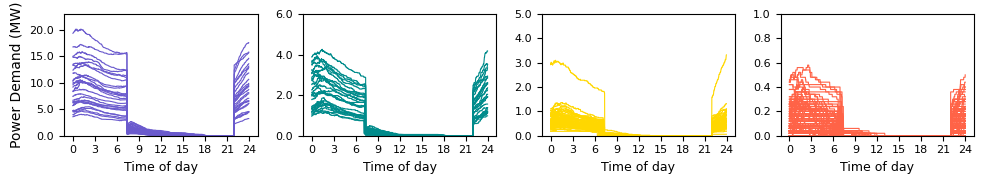

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MaxNLocator, FormatStrFormatter


fig, axes = plt.subplots(1, 4, figsize=(10, 2), sharey=False)  # sharey=True means all share same y-axis scale
axes = axes.flatten()

df_1 = df_load_all_airports_S6_large.copy()
df_1.index = df_1.index / 60
df_1 = df_1 / 1000

df_2 = df_load_all_airports_S6_medium.copy()
df_2.index = df_2.index / 60
df_2 = df_2 / 1000

df_3 = df_load_all_airports_S6_small.copy()
df_3.index = df_3.index / 60
df_3 = df_3 / 1000

df_4 = df_load_all_airports_S6_nonhub.copy()
df_4.index = df_4.index / 60
df_4 = df_4 / 1000

df_1.iloc[:, :-3].plot(ax=axes[0], color='slateblue', legend=False, linewidth=0.8)
df_2.iloc[:, :-3].plot(ax=axes[1], color='darkcyan', legend=False, linewidth=0.8)
df_3.iloc[:, :-3].plot(ax=axes[2], color='gold', legend=False, linewidth=0.8)
df_4.iloc[:, :-3].plot(ax=axes[3], color='tomato', legend=False, linewidth=0.8)

for ax in axes:
    ax.grid(False)
    ax.tick_params(axis='y', left=True, labelleft=True, labelsize = 8)
    ax.tick_params(axis='x', labelsize = 8)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=10, integer=True))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    ax.set_xlabel('Time of day')

axes[0].set_ylabel('Power Demand (MW)', fontsize=10)

# Set individual y limits (replace with your actual min and max for each)
axes[0].set_ylim(0, 23)
axes[1].set_ylim(0, 6)
axes[2].set_ylim(0, 5)
axes[3].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("Figure3_f.pdf", format='pdf', bbox_inches='tight')
plt.show()